# Projet IA — Analyse de l'attrition pour HumanForYou

## Introduction

Ce notebook a pour objectif d'analyser les données RH d'HumanForYou afin de comprendre et prédire l'attrition des employés. Conformément aux recommandations de la Commission Européenne pour une **IA digne de confiance**, ce projet est conçu comme un **outil d'aide à la décision humaine** et non comme un système automatisé de gestion des carrières.

L'analyse suit une démarche transparente et responsable, visant à identifier des leviers d'actions positifs pour le bien-être des employés.

---

## 1. Importation des bibliothèques

On importe les bibliothèques essentielles :
- **NumPy** et **Pandas** pour la manipulation des données
- **Matplotlib** et **Seaborn** pour la visualisation
- **SciPy** pour les tests statistiques (Mann-Whitney U, Chi²)
- **missingno** pour la visualisation des valeurs manquantes
- **warnings** et **os** pour la gestion de l'environnement

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
import warnings
import os

## 2. Configuration de l'environnement

Configuration des paramètres d'affichage globaux pour rendre les visualisations et sorties plus lisibles.

In [25]:
plt.rcParams['figure.figsize'] = (12, 9)
sns.set_theme()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

Configuration des classes pour le feature engineering du pipeline.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class CleaningTransformer(BaseEstimator, TransformerMixin):
    """
    Supprime les colonnes non informatives et sensibles
    pour un modèle plus éthique et plus efficace.
    """
    def __init__(self, cols_to_drop=None):
        # Liste par défaut des colonnes à retirer :
        # - constantes / non informatives
        # - sensibles (risque de biais)
        # - identifiant unique
        self.cols_to_drop = cols_to_drop if cols_to_drop else [
            'EmployeeCount', 'Over18', 'StandardHours',  # Non informatives
            'Gender', 'MaritalStatus', 'Age',            # Sensibles / discriminatoires
            'EmployeeID'                                  # Identifiant unique
        ]
    
    def fit(self, X, y=None):
        # Aucun apprentissage nécessaire : ce transformer applique
        # simplement une règle de suppression de colonnes.
        return self
    
    def transform(self, X):
        # Copie défensive pour ne pas modifier l'objet d'origine
        X = X.copy()
        # On ne supprime que les colonnes réellement présentes
        cols_present = [c for c in self.cols_to_drop if c in X.columns]
        return X.drop(columns=cols_present)


class HoursWorkedEngineer(BaseEstimator, TransformerMixin):
    """
    Calcule le nombre moyen d'heures travaillées par jour
    à partir des données de badgeage (in_time / out_time).
    """
    def __init__(self, in_time=None, out_time=None):
        self.in_time = in_time
        self.out_time = out_time

    def fit(self, X, y=None):
        # Si les données de badgeage ne sont pas fournies,
        # on initialise une série vide (pas d'enrichissement possible).
        if self.in_time is None or self.out_time is None:
            self._id_map = pd.Series(dtype=float)
            return self
            
        in_df = self.in_time.copy()
        out_df = self.out_time.copy()
        
        # 1) Préparation des colonnes de dates (hors EmployeeID)
        date_cols = [c for c in in_df.columns if c != 'EmployeeID']
        in_df[date_cols] = in_df[date_cols].apply(pd.to_datetime, errors='coerce')
        out_df[date_cols] = out_df[date_cols].apply(pd.to_datetime, errors='coerce')
        
        # 2) Calcul de la durée travaillée quotidienne en heures
        # (NaN conservé pour les jours sans badgeage/absence)
        work_duration = out_df[date_cols] - in_df[date_cols]
        work_duration_hours = work_duration.apply(lambda col: col.dt.total_seconds() / 3600)
        
        # 3) Moyenne annuelle des heures par employé
        avg_hours_series = work_duration_hours.mean(axis=1)
        
        # 4) Création d'une table de correspondance EmployeeID -> avg_hours_worked
        self._id_map = pd.Series(avg_hours_series.values, index=in_df['EmployeeID'])
        return self
    
    def transform(self, X):
        # Copie défensive pour éviter toute modification de X en place
        X = X.copy()
        # Ajout de la feature uniquement si EmployeeID est présent
        if 'EmployeeID' in X.columns:
            X['avg_hours_worked'] = X['EmployeeID'].map(self._id_map)
        return X

## 3. Chargement et fusion des données

Les données sont réparties dans plusieurs fichiers CSV. On les fusionne en un seul DataFrame `employee_data` via l'identifiant commun `EmployeeID`.

- `general_data.csv` — informations générales (âge, département, salaire, etc.)
- `employee_survey_data.csv` — enquête de satisfaction des employés
- `manager_survey_data.csv` — évaluations des managers
- `in_time.csv` / `out_time.csv` — horaires de présence (utilisés en section 5)

In [26]:
data_dir = 'data'

employee_survey = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'employee_survey_data.csv'))
general_data    = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'general_data.csv'))
manager_survey  = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'manager_survey_data.csv'))
in_time         = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time', 'in_time.csv'))
out_time        = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time', 'out_time.csv'))

in_time.rename(columns={in_time.columns[0]: 'EmployeeID'}, inplace=True)
out_time.rename(columns={out_time.columns[0]: 'EmployeeID'}, inplace=True)

# Fusion des données RH
employee_data = pd.merge(general_data, employee_survey, on='EmployeeID', how='left')
employee_data = pd.merge(employee_data, manager_survey, on='EmployeeID', how='left')

print(f'Shape du dataset fusionné : {employee_data.shape}')
employee_data.head()
employee_data.describe(include='all').T

preprocessed_data = employee_data.copy()

Shape du dataset fusionné : (4410, 29)


## 4. Feature engineering — Heures travaillées

Les fichiers `in_time` et `out_time` contiennent les horaires d'arrivée et de départ de chaque employé pour chaque jour de l'année 2015.

On calcule ici, pour chaque employé :
- **`avg_hours_worked`** — durée de travail quotidienne moyenne (en heures)

**Traitement :**
- Conversion des colonnes de timestamps en objets `datetime`
- Calcul de la durée journalière pour chaque présence (NaN si absent ce jour-là)
- Moyenne par employé sur l'ensemble de l'année

Une fois la fusion effectuée, `EmployeeID` est supprimé et les listes de colonnes sont mises à jour.

> **Note :** Les jours d'absence sont exclus du calcul (non comptés comme 0h travaillée).

In [27]:
# Conversion des colonnes de dates
date_cols = [c for c in in_time.columns if c != 'EmployeeID']
in_time[date_cols]  = in_time[date_cols].apply(pd.to_datetime, errors='coerce')
out_time[date_cols] = out_time[date_cols].apply(pd.to_datetime, errors='coerce')

# Calcul de la durée quotidienne en heures (NaN si absent)
work_duration       = out_time[date_cols] - in_time[date_cols]
work_duration_hours = work_duration.apply(lambda col: col.dt.total_seconds() / 3600)

# Moyenne par employé sur l'année
avg_hours = work_duration_hours.mean(axis=1)
hours_df  = pd.DataFrame({'EmployeeID': in_time['EmployeeID'], 'avg_hours_worked': avg_hours})

# Fusion dans le dataset principal
employee_data = pd.merge(employee_data, hours_df, on='EmployeeID', how='left')

# Suppression de EmployeeID (identifiant sans pouvoir prédictif)
employee_data.drop(columns=['EmployeeID'], inplace=True)
print('✓ avg_hours_worked ajouté, EmployeeID supprimé.')

# Recalcul final des colonnes (avg_hours_worked inclus, EmployeeID exclu)
numerical_columns   = employee_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numériques finales ({len(numerical_columns)}) :')
print(numerical_columns)
print(f'\nVariables catégorielles finales ({len(categorical_columns)}) :')
print(categorical_columns)
print(f'\nShape finale : {employee_data.shape}')
employee_data[['avg_hours_worked']].describe()

✓ avg_hours_worked ajouté, EmployeeID supprimé.

Variables numériques finales (21) :
['Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked']

Variables catégorielles finales (8) :
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18']

Shape finale : (4410, 29)


,avg_hours_worked
count,4410.00
mean,7.70
std,1.34
min,5.95
25%,6.67
50%,7.41
75%,8.37
max,11.03


## 5. Préparation des données (Éthique : Anonymisation et nettoyage)\n

Cette étape regroupe tout le nettoyage **avant toute analyse**. Dans une optique de **confidentialité et de gouvernance des données (RGPD)** :

- **Anonymisation** : L'identifiant `EmployeeID` est supprimé car il ne contient aucune information prédictive et permettrait d'isoler des individus.
- **Élagage** : Les colonnes constantes sont supprimées pour alléger le modèle et éviter le stockage de données inutiles.

### 5.1 Gestion des valeurs manquantes

**Stratégie d'imputation :**
- **Variables numériques** → remplacement par la **médiane** (robuste aux valeurs aberrantes).
- **Variables catégorielles** → remplacement par le **mode** (valeur la plus fréquente).

### 5.2 Suppression des colonnes non informatives

Colonnes présentant une valeur unique pour tous les employés — aucun pouvoir discriminant :
- **`EmployeeCount`** — toujours égal à 1
- **`Over18`** — toujours égal à `Y`
- **`StandardHours`** — toujours égal à 8

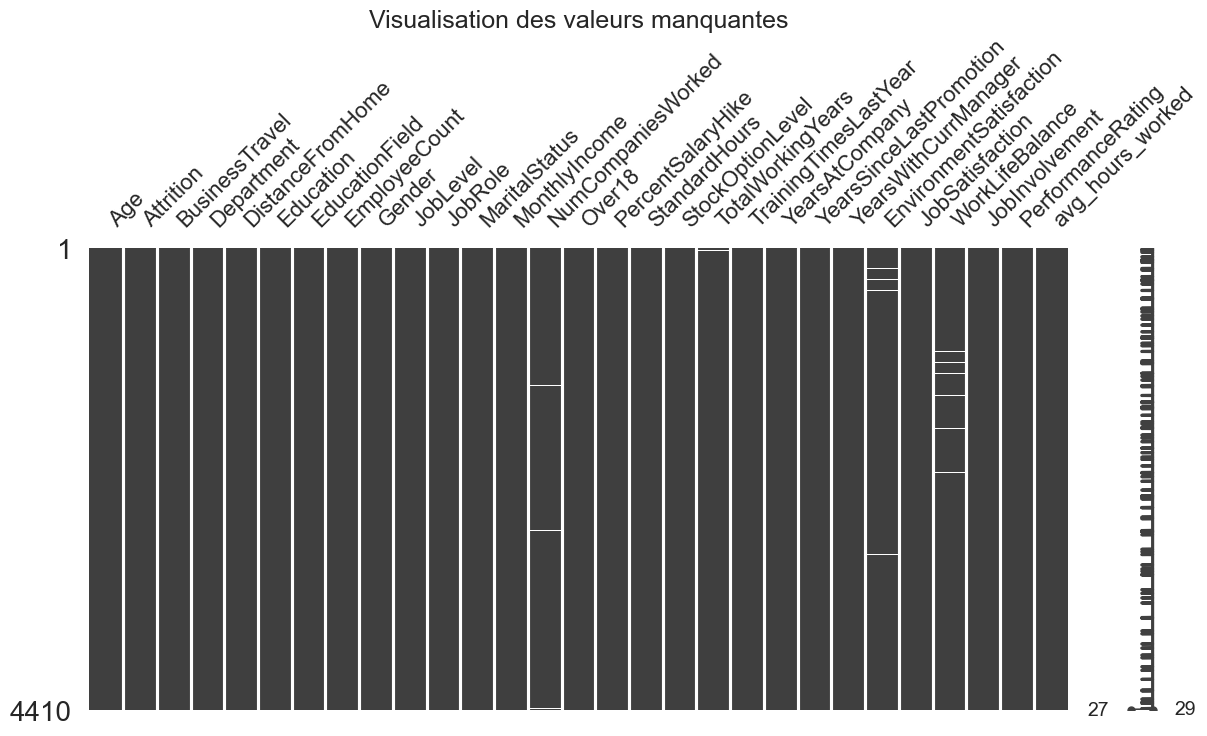


Colonnes supprimées (valeur unique) : ['EmployeeCount', 'Over18', 'StandardHours']
Shape après nettoyage : (4410, 26)

Variables numériques (19) : ['Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_hours_worked']
Variables catégorielles (7) : ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [ ]:
# --- 5.1 Valeurs manquantes ---

# Visualisation
msno.matrix(employee_data, figsize=(14, 6))
plt.title('Visualisation des valeurs manquantes')
plt.show()

# NOTE : L'imputation (remplacement des valeurs manquantes) est volontairement 
# omise ici pour éviter les fuites de données (Data Leakage).
# Elle sera effectuée dans la section 12, après la séparation des données 
# en ensembles d'entraînement et de test.

# --- 5.2 Suppression des colonnes non informatives ---
# EmployeeID conservé temporairement pour la fusion des horaires (section 5)
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
employee_data.drop(columns=cols_to_drop, inplace=True)
print(f'\nColonnes supprimées (valeur unique) : {cols_to_drop}')
print(f'Shape après nettoyage : {employee_data.shape}')

# Recalcul des colonnes — EmployeeID exclu car identifiant technique
numerical_columns   = [c for c in employee_data.select_dtypes(include=['float64', 'int64']).columns
                        if c != 'EmployeeID']
categorical_columns = employee_data.select_dtypes(include=['object']).columns.tolist()

print(f'\nVariables numériques ({len(numerical_columns)}) : {numerical_columns}')
print(f'Variables catégorielles ({len(categorical_columns)}) : {categorical_columns}')

### Normalisation avant analyse bivariée

Avant de réaliser une analyse bivariée (corrélation, tests statistiques), il est important de vérifier si les variables quantitatives sont sur des échelles comparables. Si ce n’est pas le cas, une normalisation (par exemple MinMaxScaler ou StandardScaler) permet d’éviter que certaines variables dominent l’analyse à cause de leur plage de valeurs.

Dans ce projet, nous avons normalisé les variables quantitatives avant d’effectuer les analyses bivariées afin d’assurer la robustesse des résultats.

In [29]:
# 3. Vérification de la plage de JobSatisfaction et normalisation éventuelle

# Vérification de la plage
print('Plage de JobSatisfaction :', employee_survey['JobSatisfaction'].min(), '-', employee_survey['JobSatisfaction'].max())

# Si besoin, normalisation sur [0,1]
if employee_survey['JobSatisfaction'].min() < 1 or employee_survey['JobSatisfaction'].max() > 4:
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    employee_survey['JobSatisfaction_norm'] = scaler.fit_transform(employee_survey[['JobSatisfaction']])
    print('JobSatisfaction normalisé sur [0,1]')
else:
    print('JobSatisfaction déjà sur l’échelle attendue (1-4)')

Plage de JobSatisfaction : 1.0 - 4.0
JobSatisfaction déjà sur l’échelle attendue (1-4)


## 6. Distribution de la variable cible — Attrition

Avant toute analyse des variables, il est essentiel de visualiser la distribution de la variable cible `Attrition`.

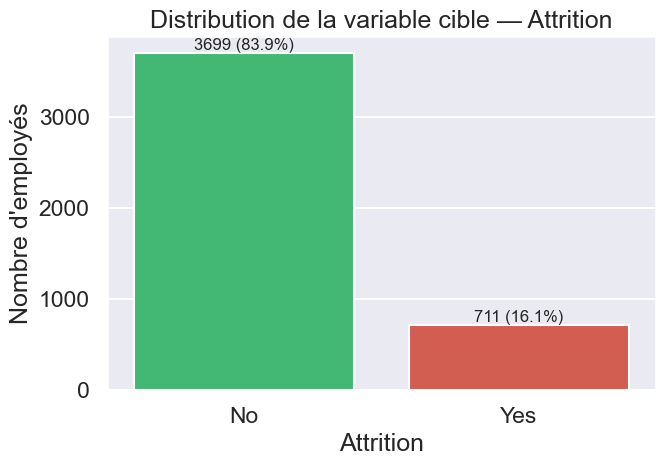

Classe No  : 3699 employés (83.9%)
Classe Yes : 711 employés (16.1%)


In [30]:
attrition_counts = employee_data['Attrition'].value_counts()
attrition_pct    = employee_data['Attrition'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Attrition', data=employee_data, palette=['#2ecc71', '#e74c3c'])
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())} ({p.get_height()/len(employee_data)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12
    )
plt.title('Distribution de la variable cible — Attrition')
plt.xlabel('Attrition')
plt.ylabel("Nombre d'employés")
plt.tight_layout()
plt.show()

print(f'Classe No  : {attrition_counts["No"]} employés ({attrition_pct["No"]:.1f}%)')
print(f'Classe Yes : {attrition_counts["Yes"]} employés ({attrition_pct["Yes"]:.1f}%)')

## 7. Analyse univariée des variables

Cette étape consiste à examiner chaque variable individuellement pour comprendre sa distribution.

- **Variables numériques** : si la variable prend moins de 10 valeurs distinctes → `countplot` (variable ordinale/discrète) ; sinon → histogramme + courbe de densité (KDE).
- **Variables catégorielles** : fréquences par modalité avec un `countplot`.

Cette exploration permet de détecter des déséquilibres, des distributions atypiques et des variables peu discriminantes.

> **Point d'attention :** `PerformanceRating` ne prend que les valeurs 3 et 4 dans ce dataset — variable a priori peu discriminante.

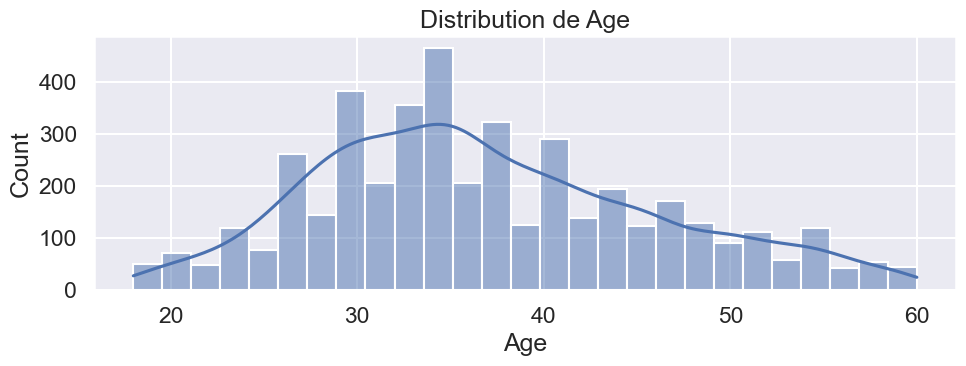

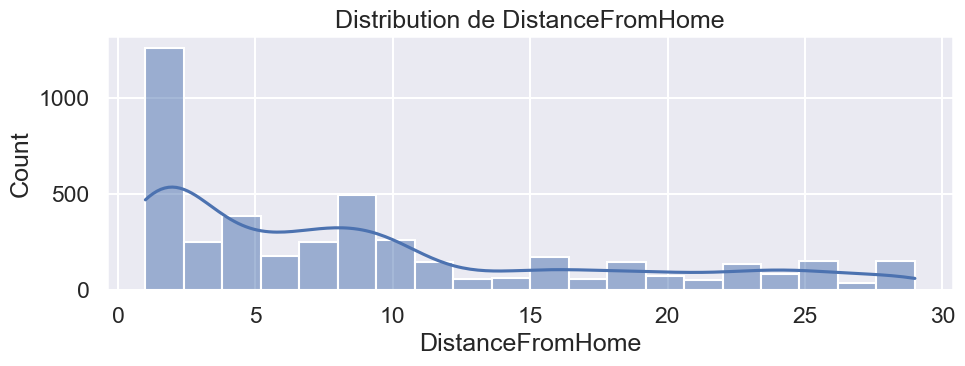

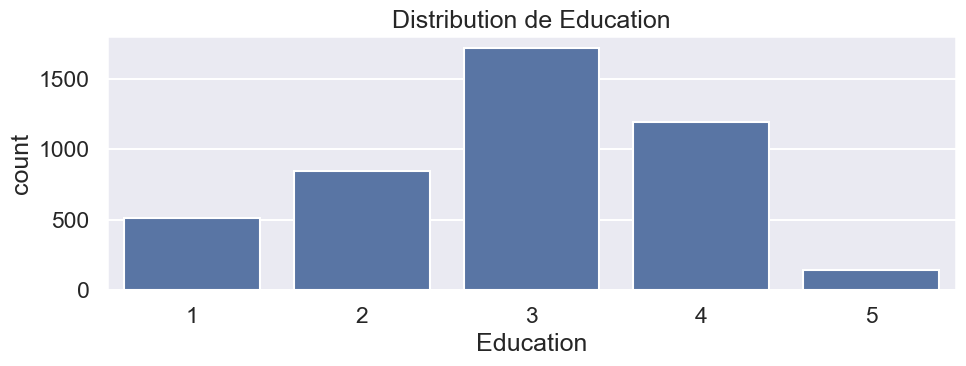

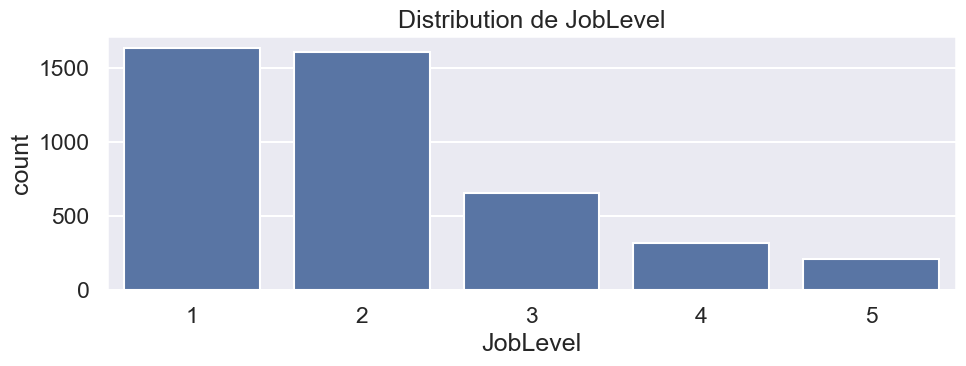

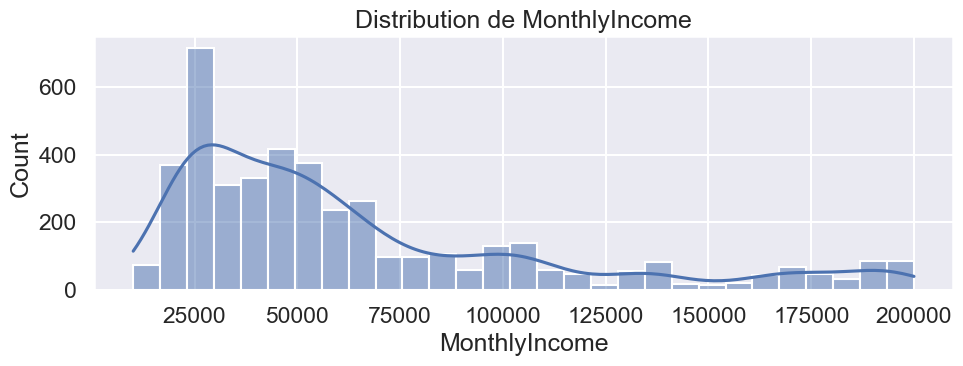

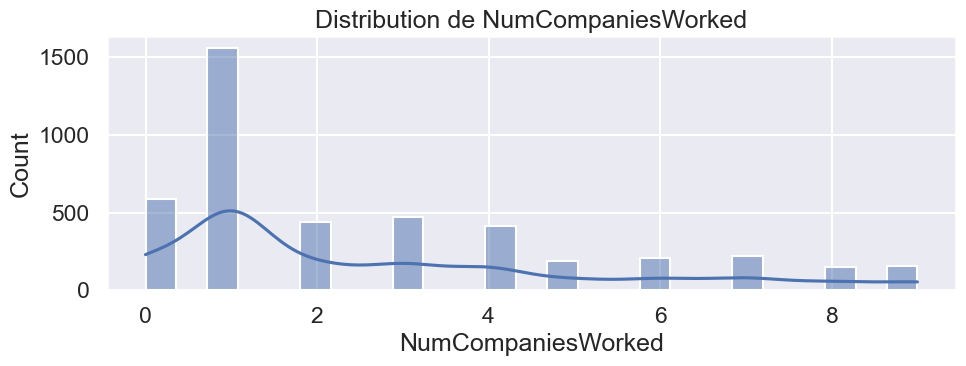

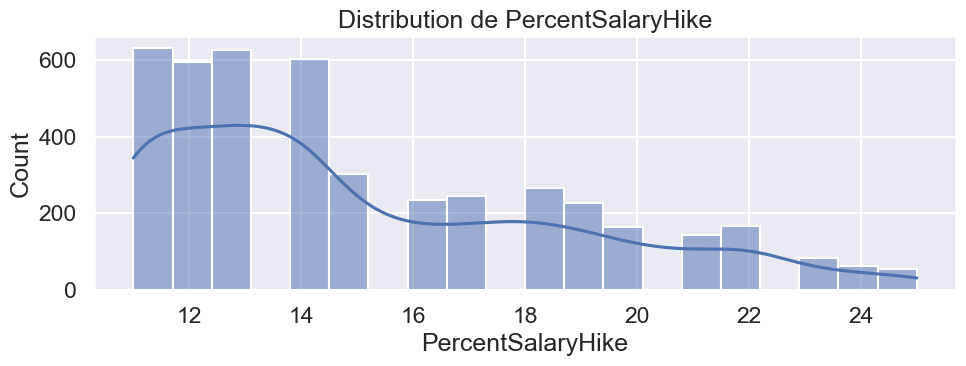

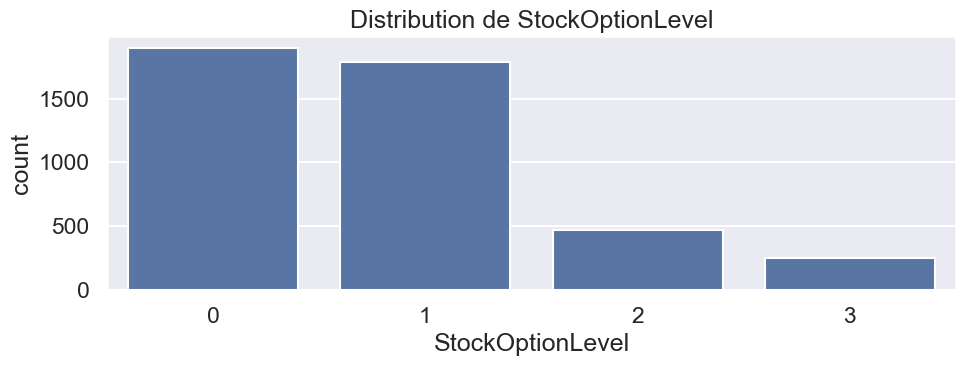

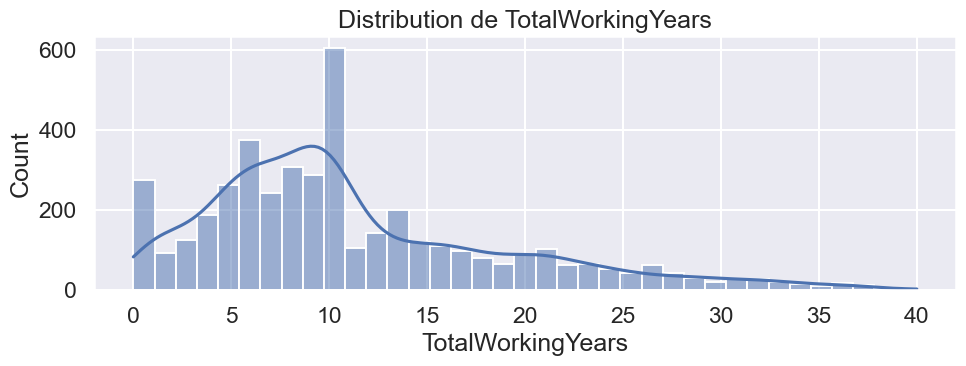

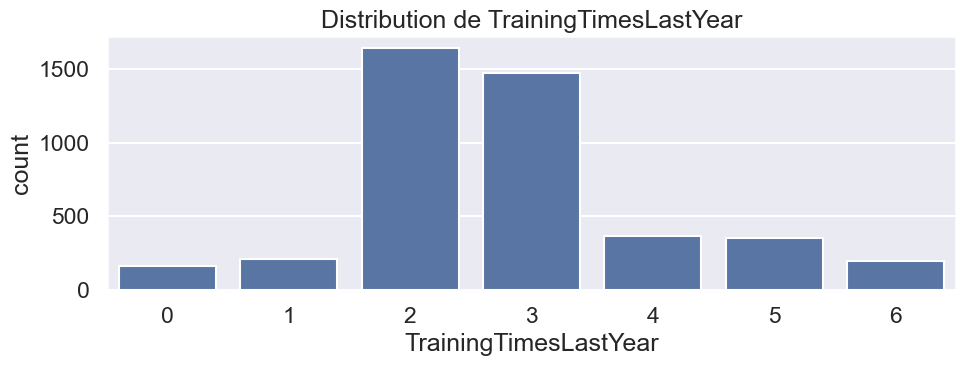

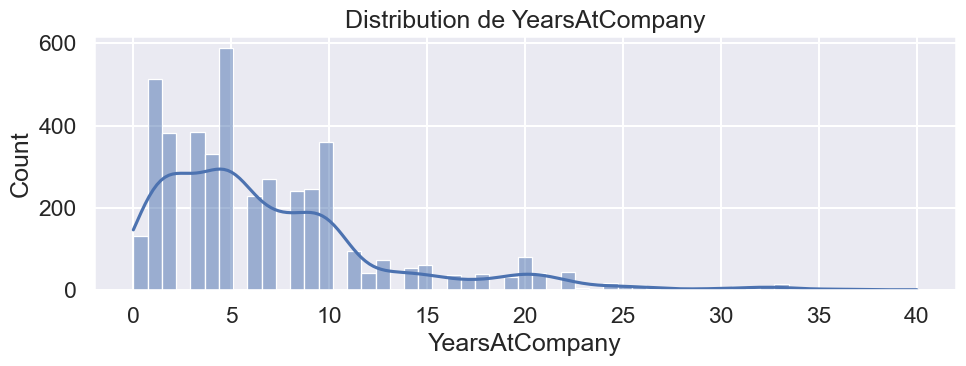

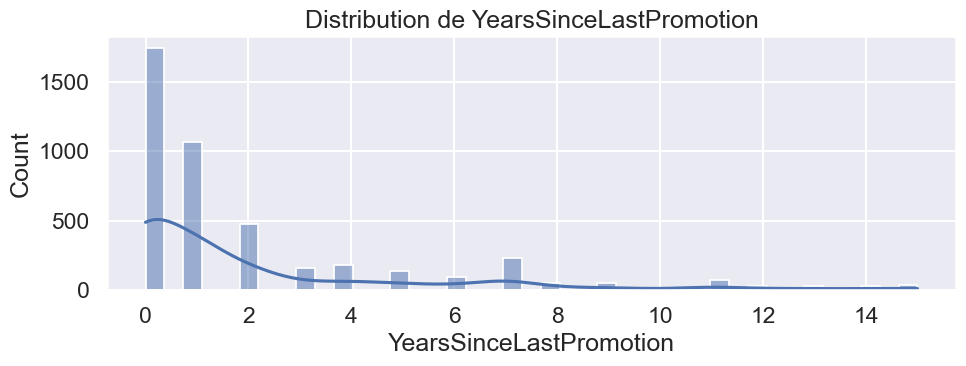

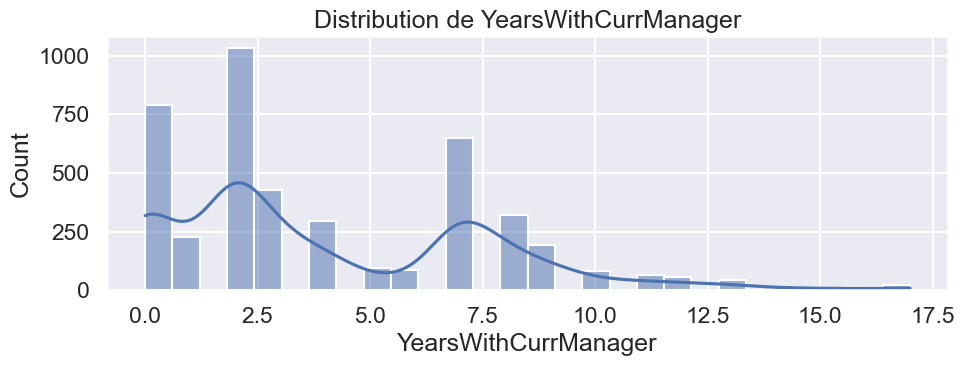

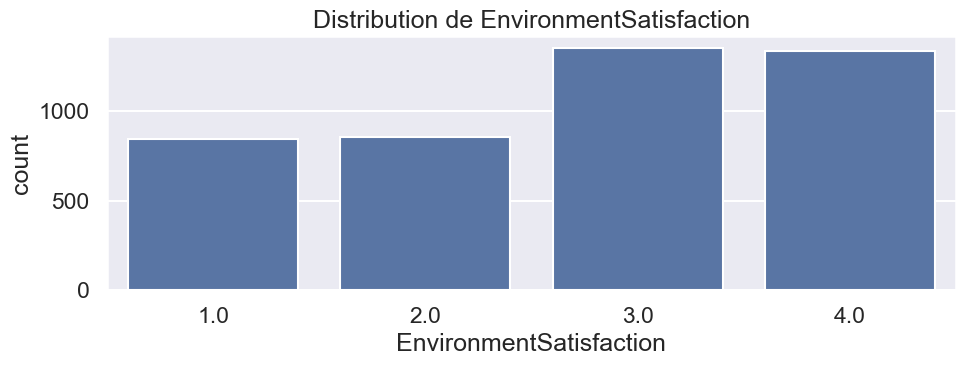

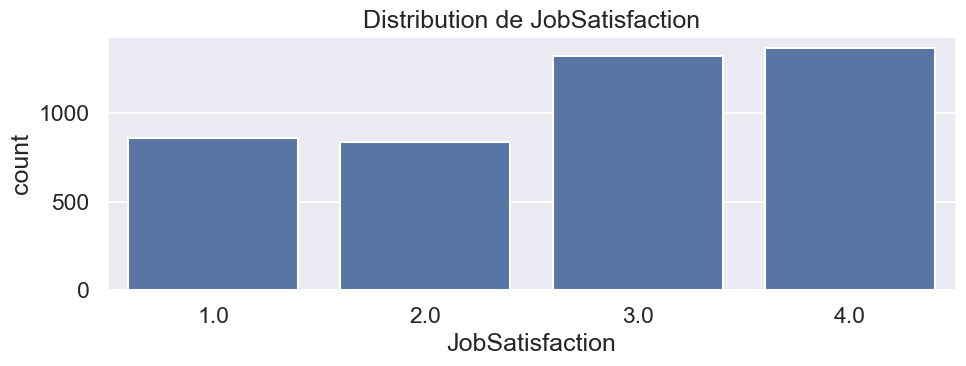

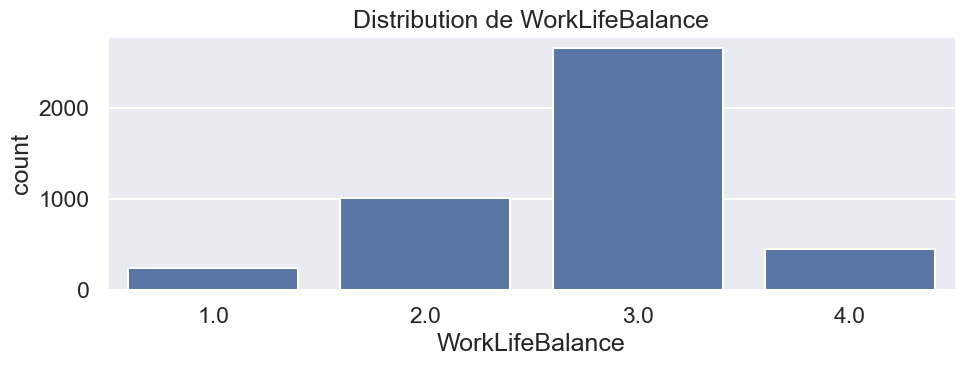

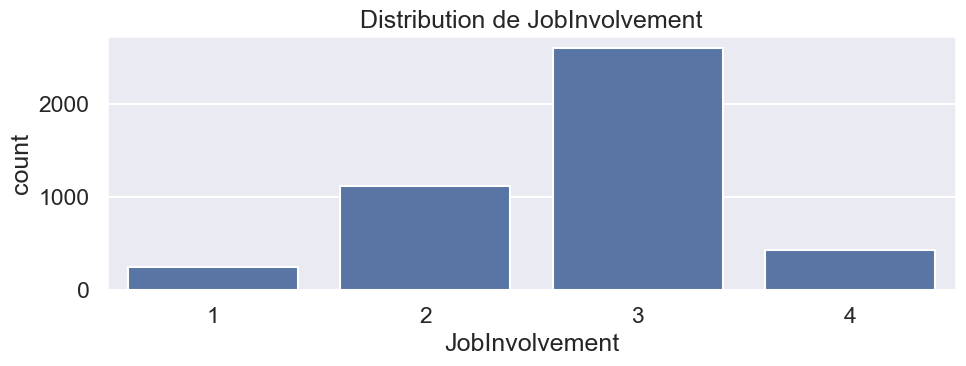

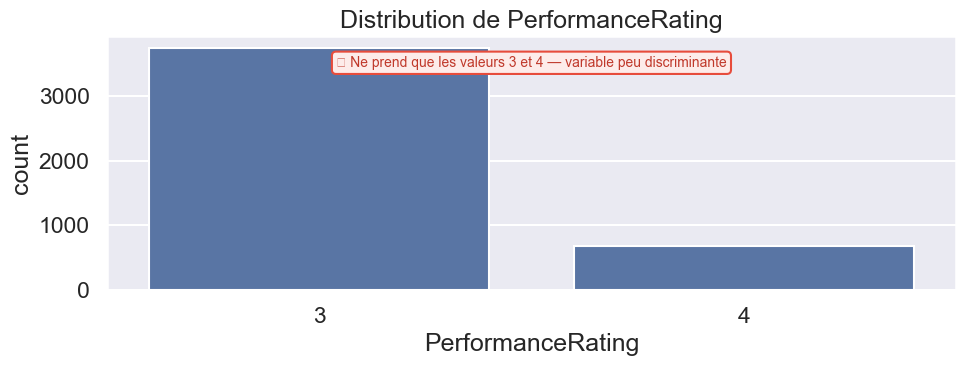

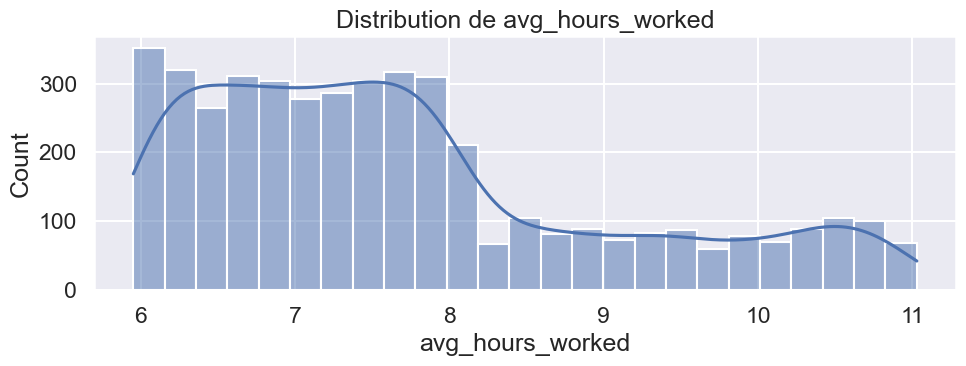

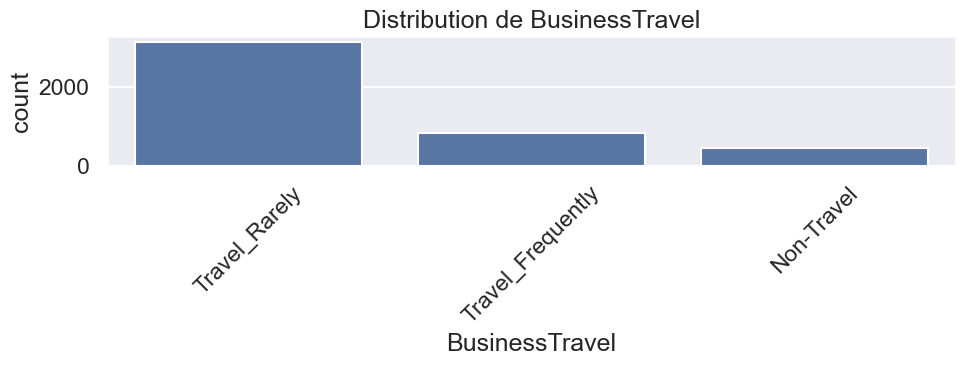

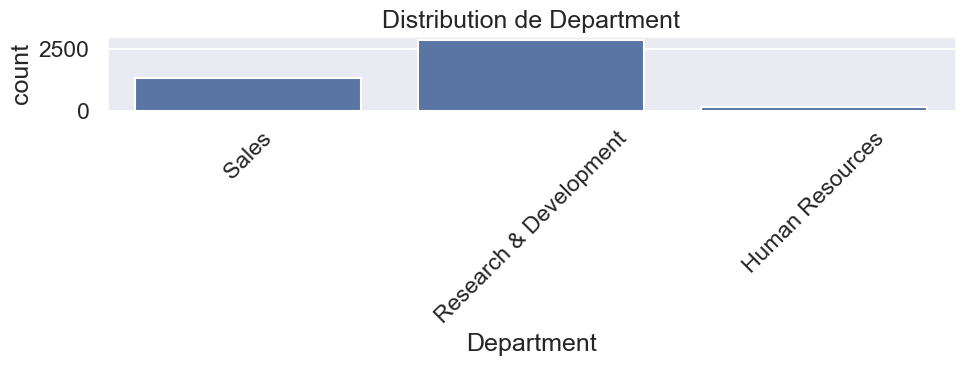

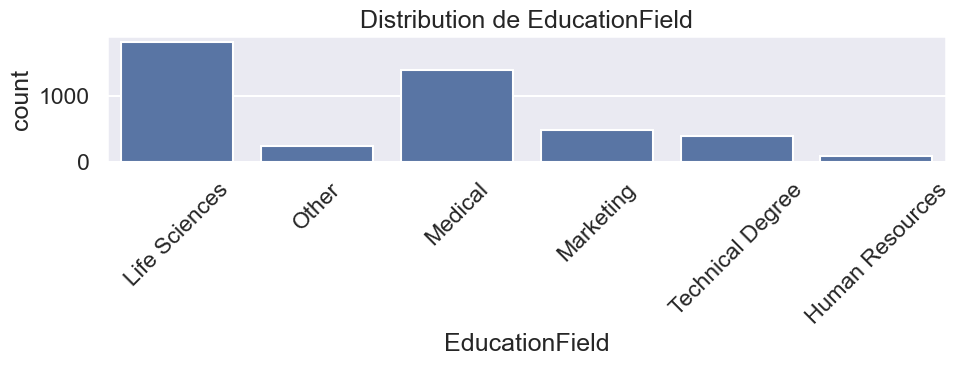

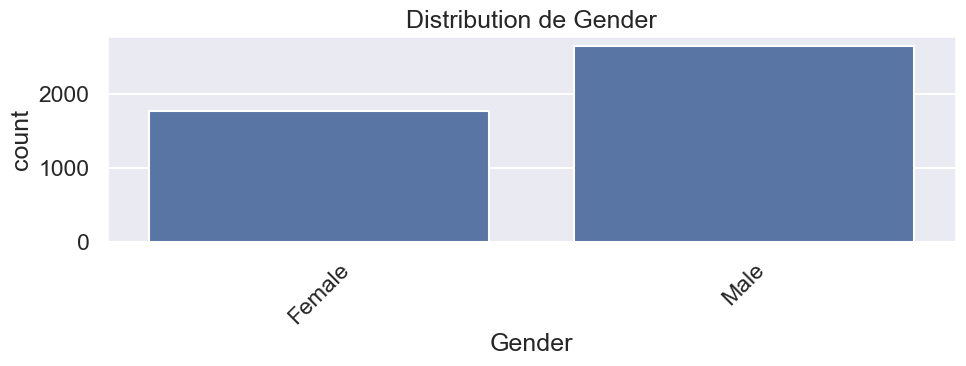

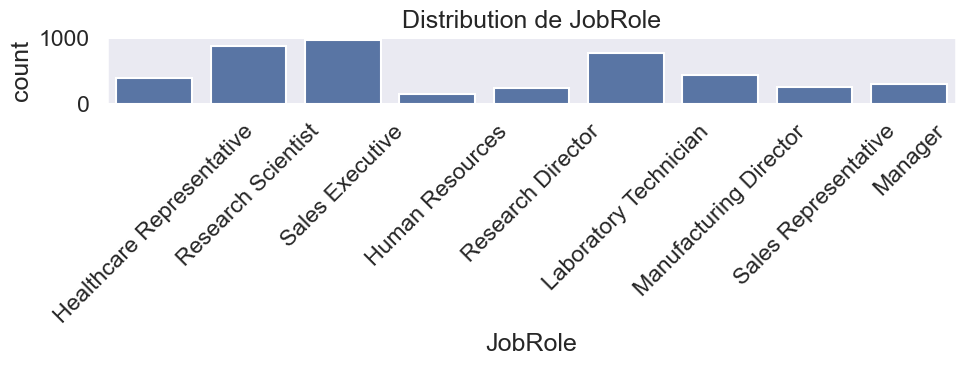

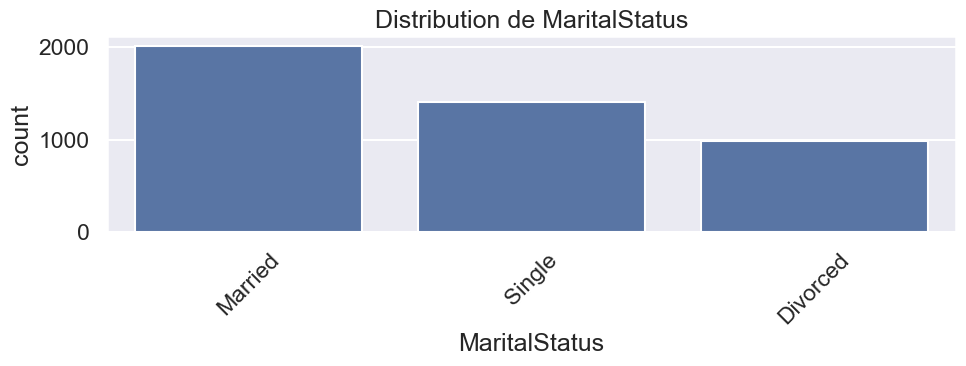

In [31]:
# --- Variables numériques ---
for column in numerical_columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    if employee_data[column].nunique() < 10:
        sns.countplot(x=employee_data[column], ax=ax)
    else:
        sns.histplot(employee_data[column], kde=True, ax=ax)
    ax.set_title(f'Distribution de {column}')
    # Alerte pour PerformanceRating (seulement valeurs 3 et 4)
    if column == 'PerformanceRating':
        ax.text(0.5, 0.88,
                '⚠ Ne prend que les valeurs 3 et 4 — variable peu discriminante',
                transform=ax.transAxes, ha='center', fontsize=10, color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', edgecolor='#e74c3c'))
    plt.tight_layout()
    plt.show()

# --- Variables catégorielles (hors Attrition) ---
for column in categorical_columns:
    if column == 'Attrition':
        continue
    plt.figure(figsize=(10, 4))
    sns.countplot(x=employee_data[column])
    plt.title(f'Distribution de {column}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Analyse bivariée — Variables vs Attrition

L'analyse bivariée consiste à croiser chaque variable avec la variable cible `Attrition` pour identifier les facteurs les plus discriminants.

**Note éthique (Équité et Non-discrimination) :** 
Certaines variables comme `Gender`, `Age` et `MaritalStatus` sont des critères protégés. Bien qu'elles puissent être statistiquement corrélées à l'attrition, leur utilisation pour des décisions individuelles (ex: ciblage de rétention basé sur le sexe) est **éthiquement problématique et légalement encadrée**. Elles sont conservées ici à des fins de surveillance des biais, mais ne doivent pas constituer des critères de décision automatiques.

- **Variables numériques** : comparaison des distributions via des `boxplots`, validée par un **test de Mann-Whitney U** (test non paramétrique adapté aux distributions non normales).
- **Variables catégorielles** : taux d'attrition par modalité, validé par un **test du Chi²** (indépendance entre la variable et Attrition).

**Lecture :** un p-value < 0.05 indique que la différence observée est statistiquement significative.

Cette étape est centrale pour répondre à la question métier : *quels sont les facteurs ayant le plus d'influence sur le départ des employés ?*

VARIABLES NUMÉRIQUES vs ATTRITION (Mann-Whitney U)


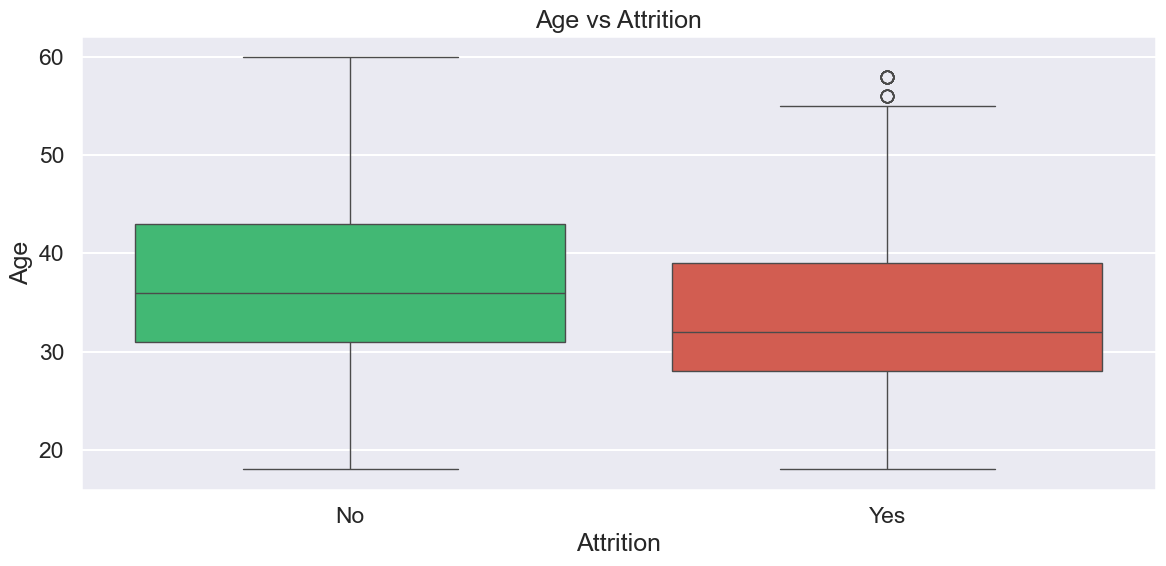

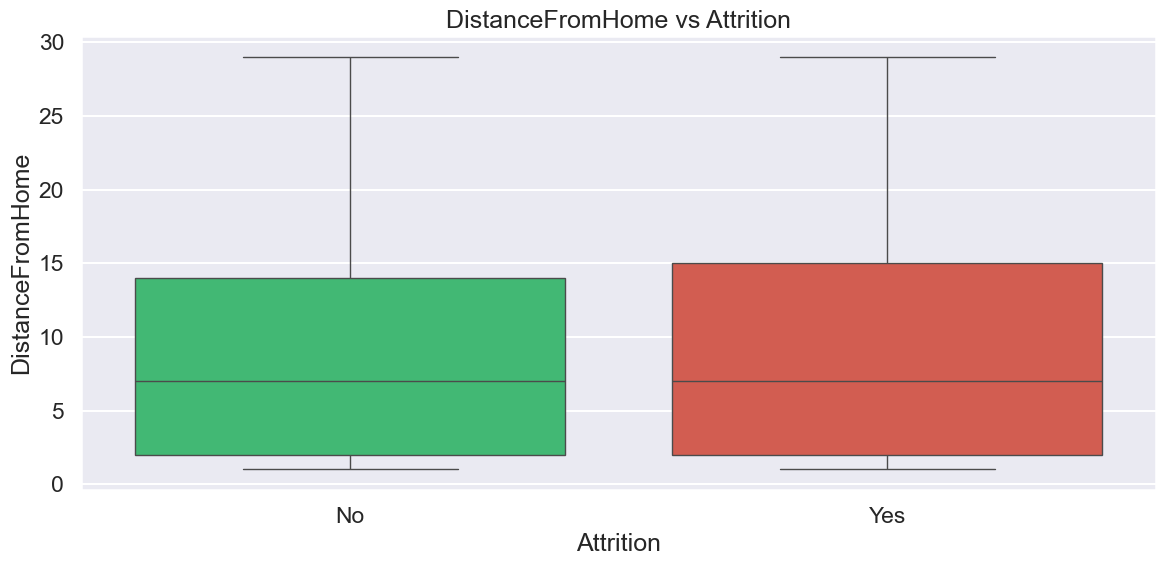

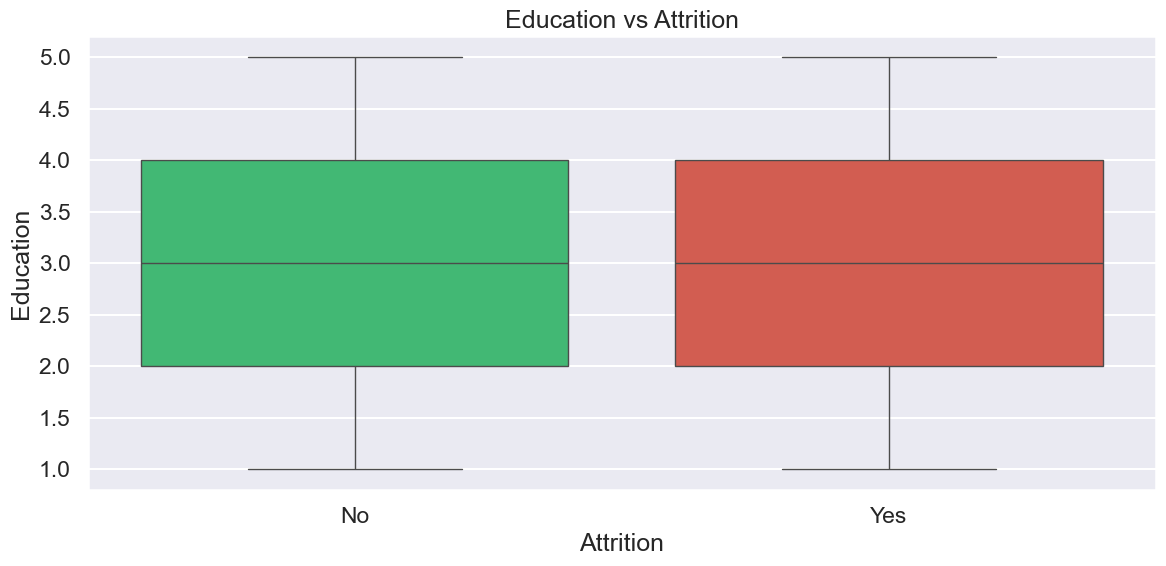

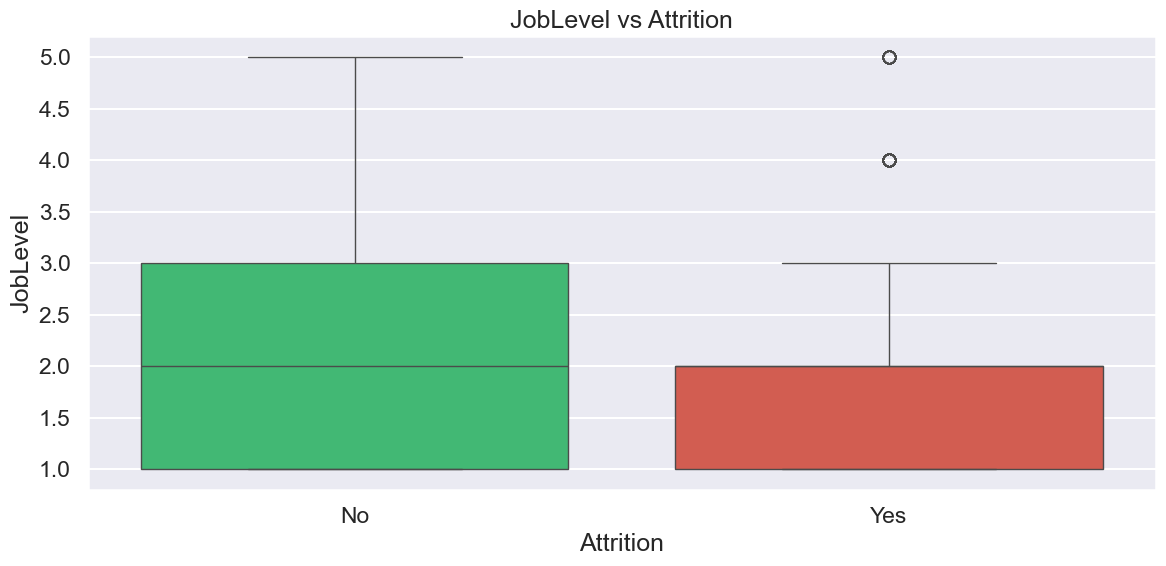

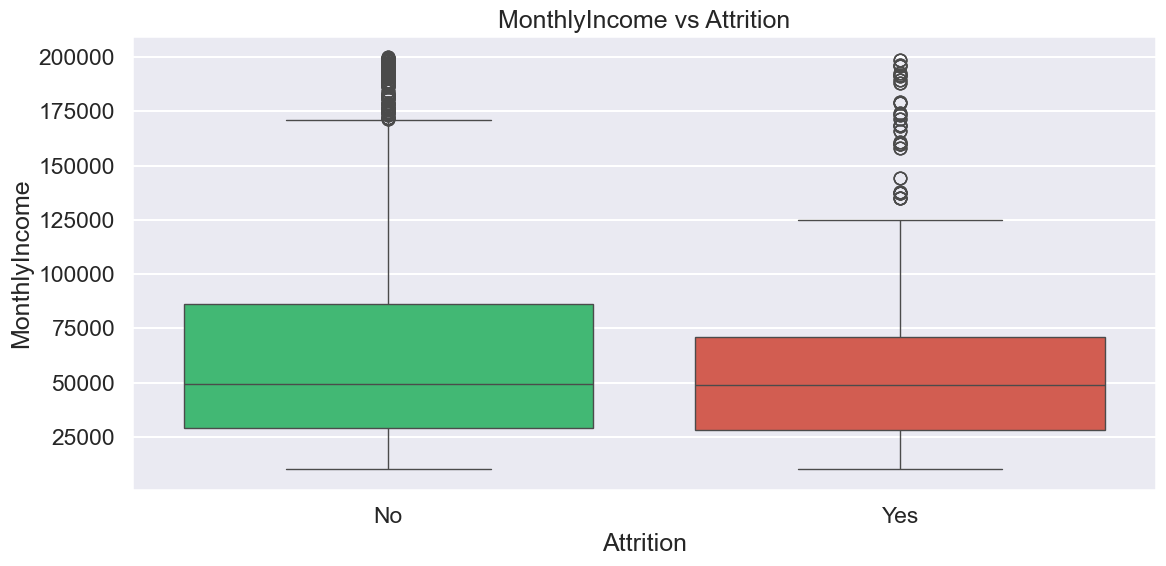

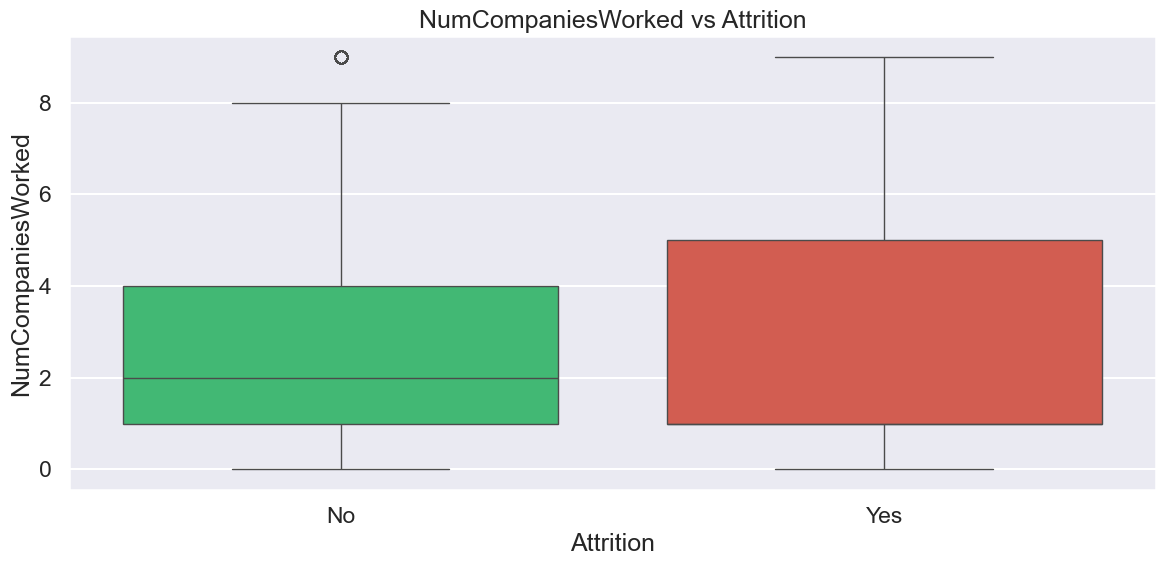

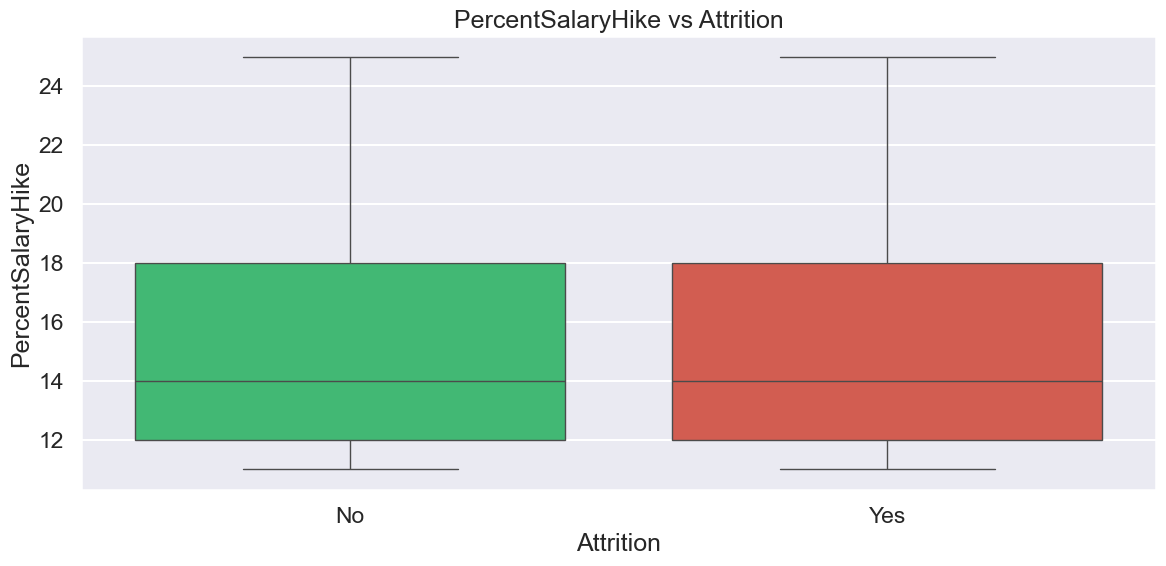

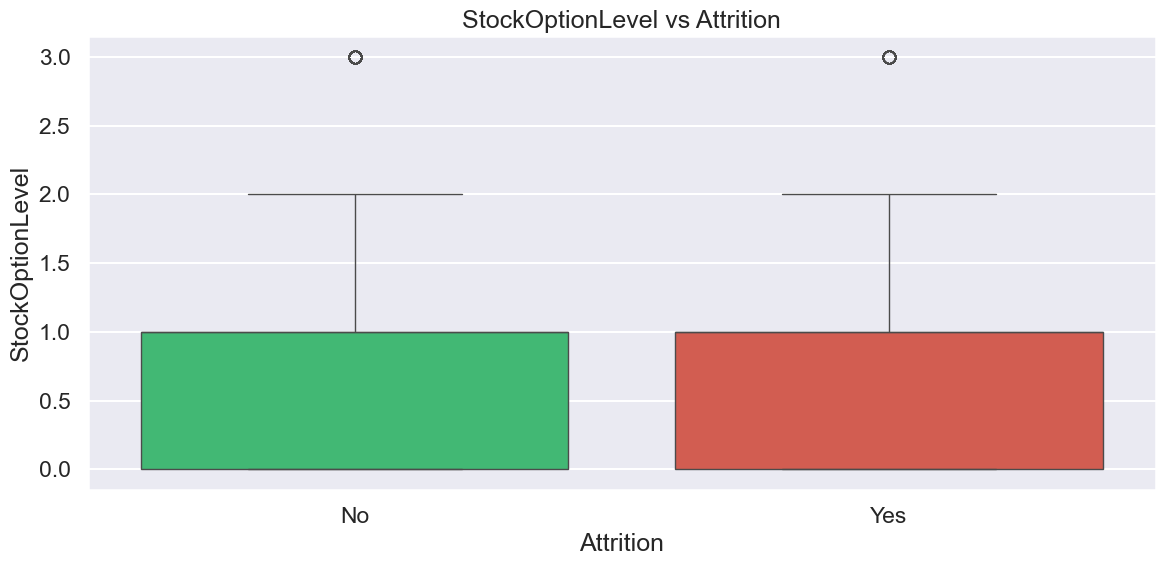

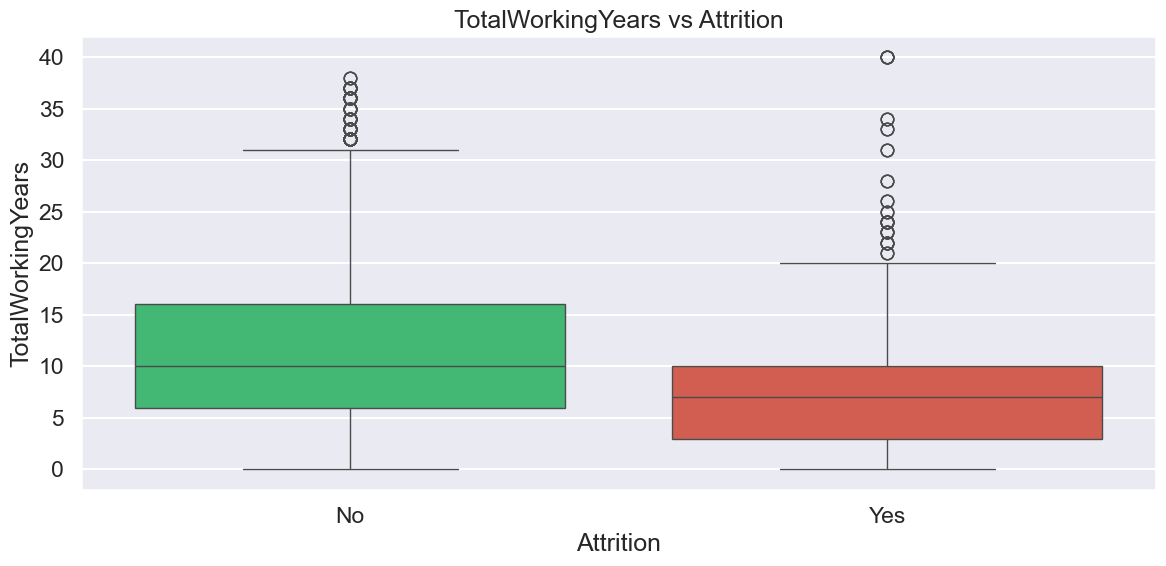

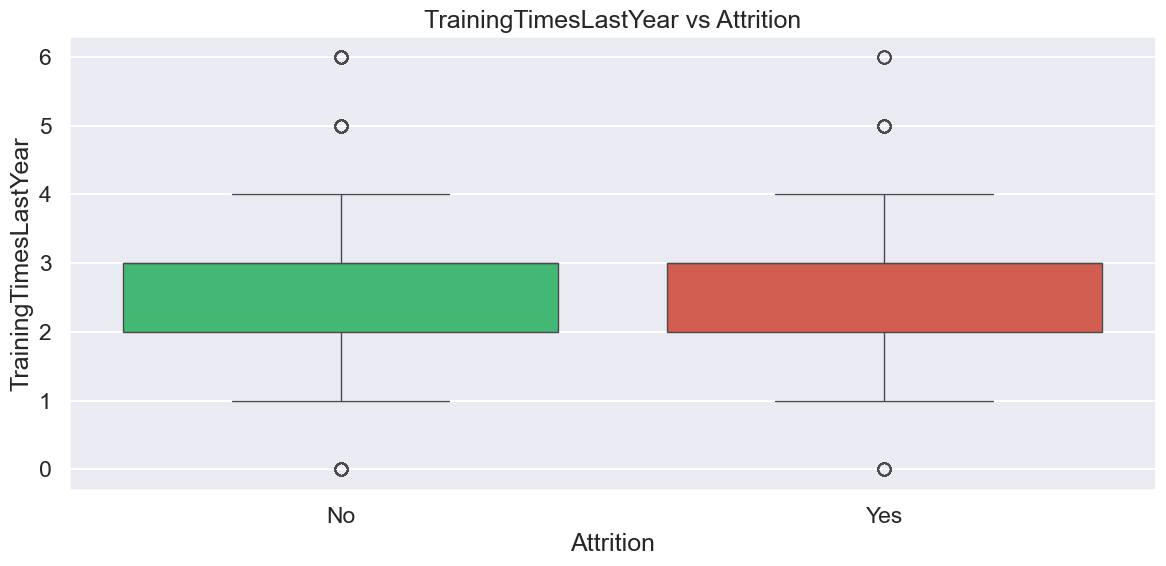

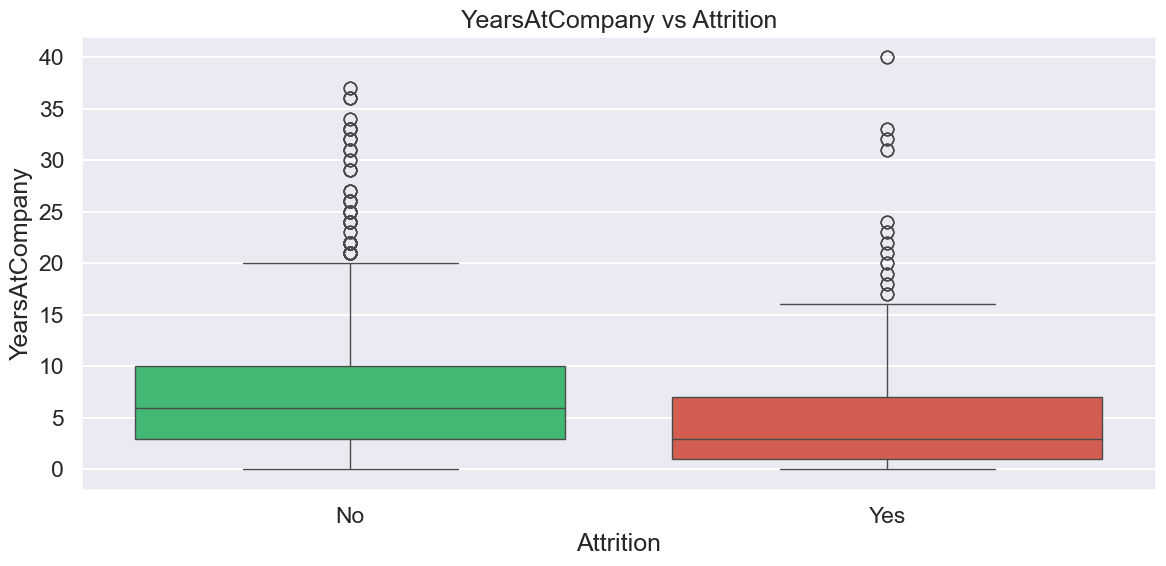

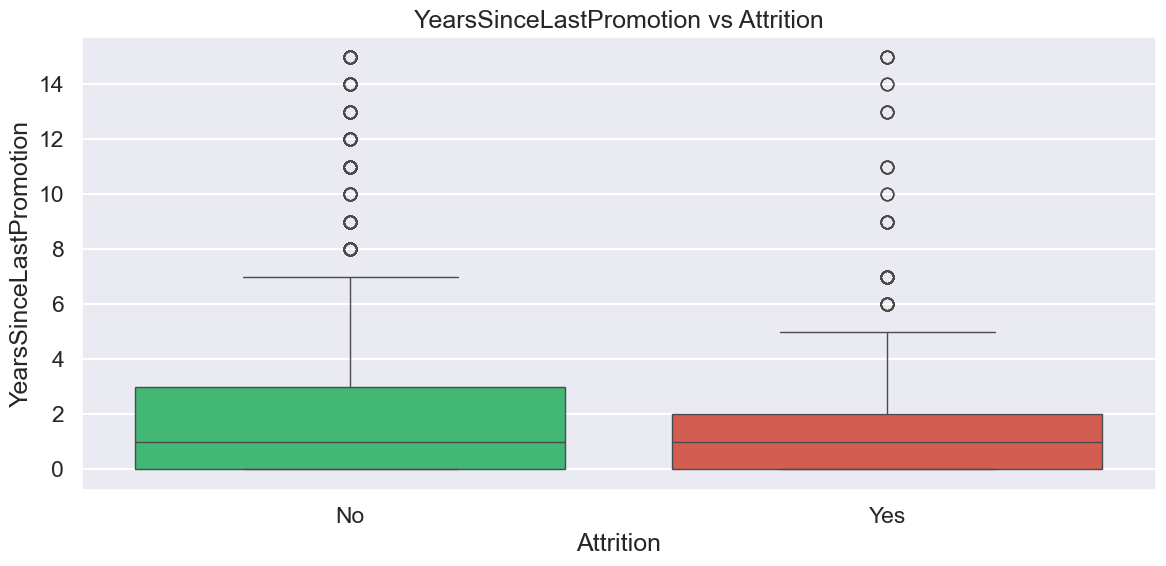

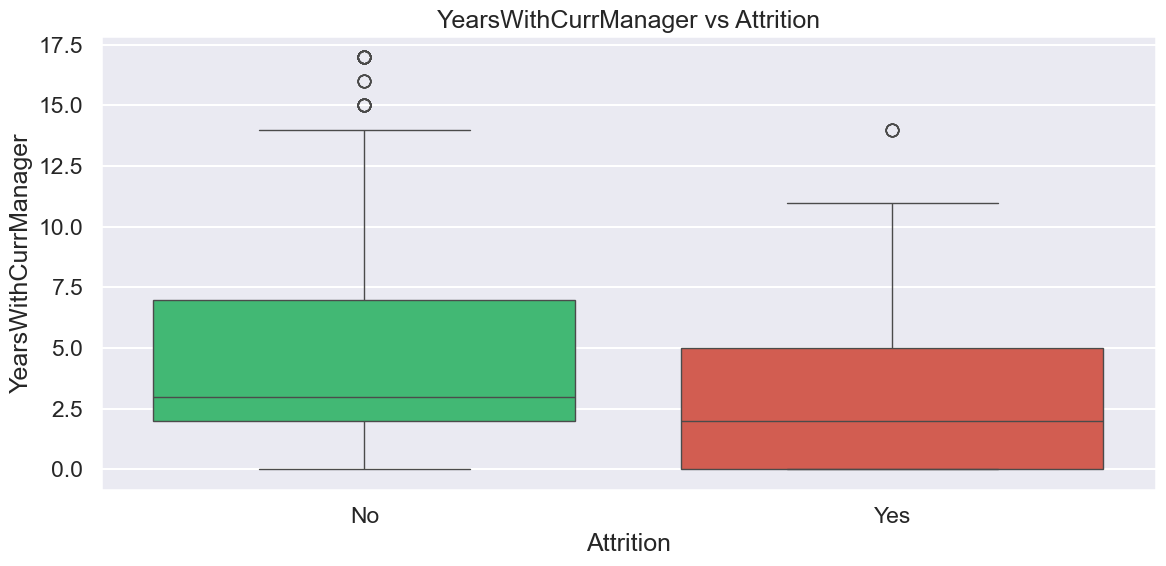

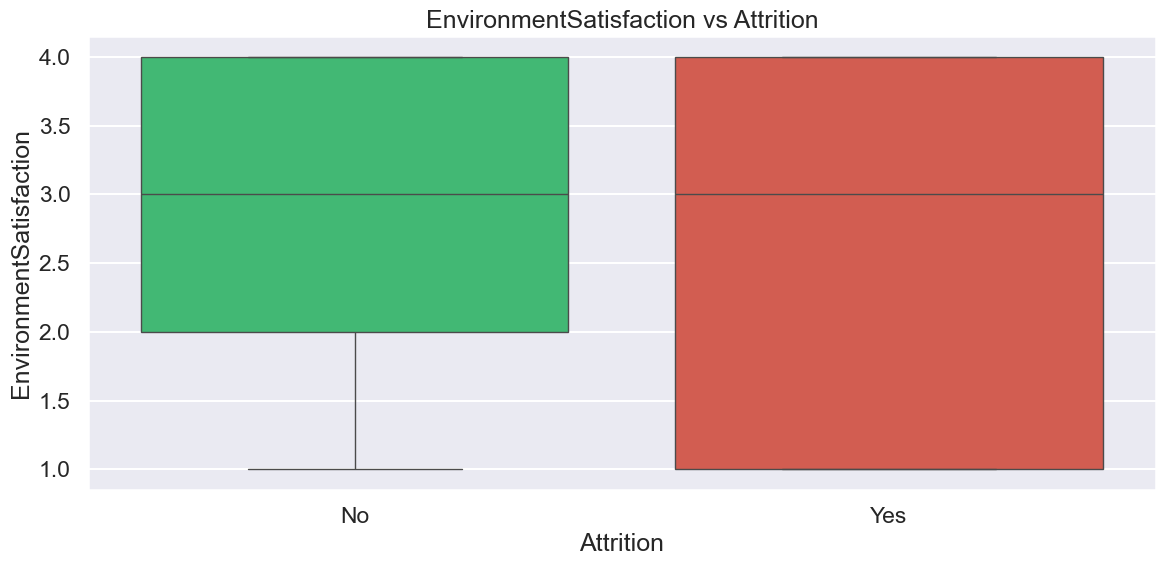

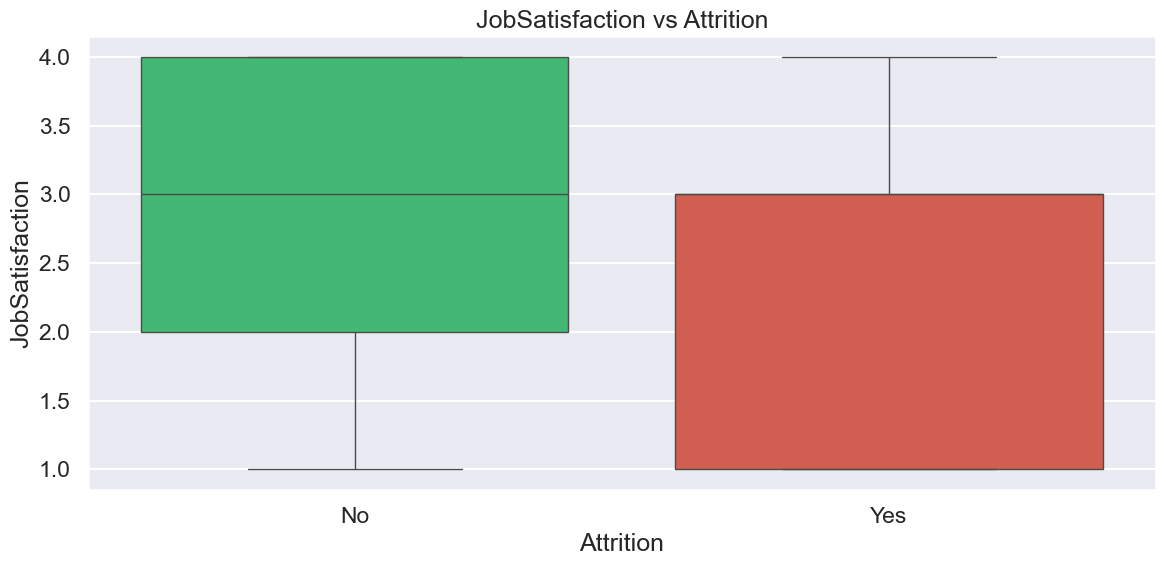

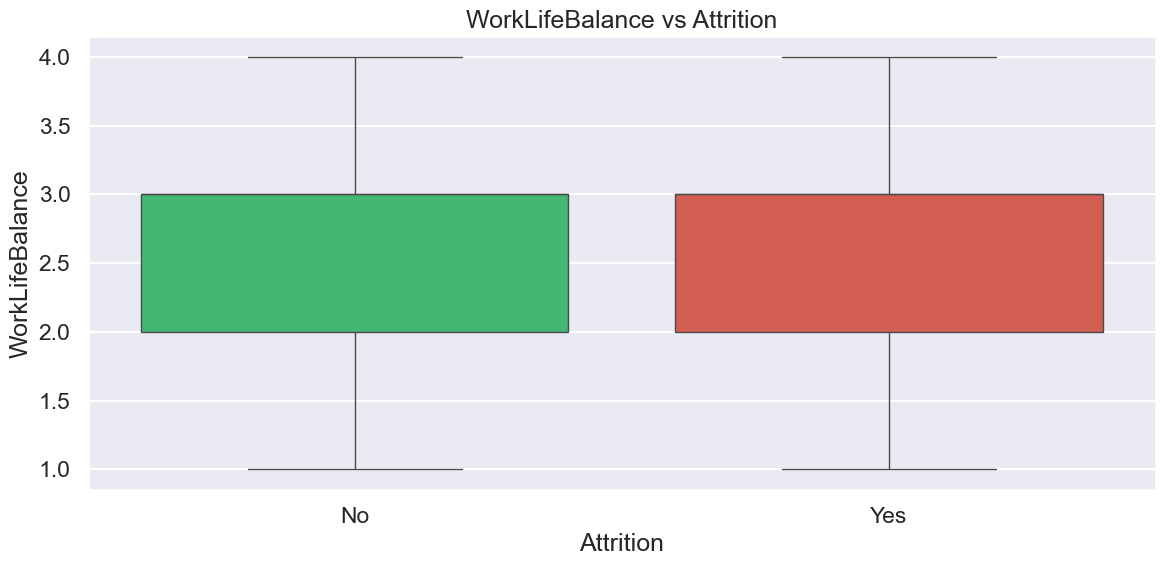

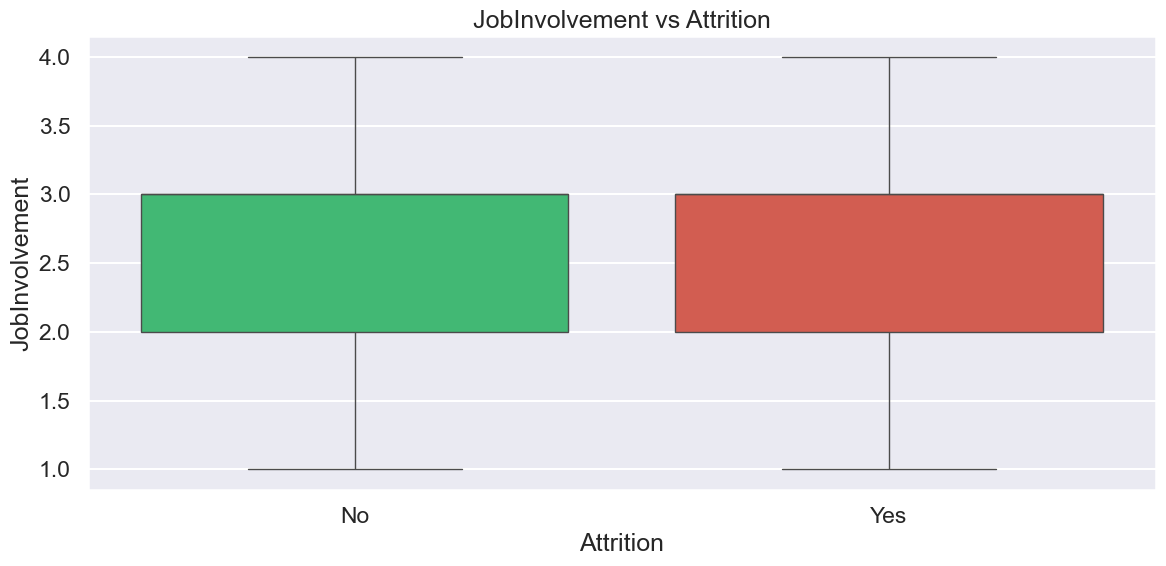

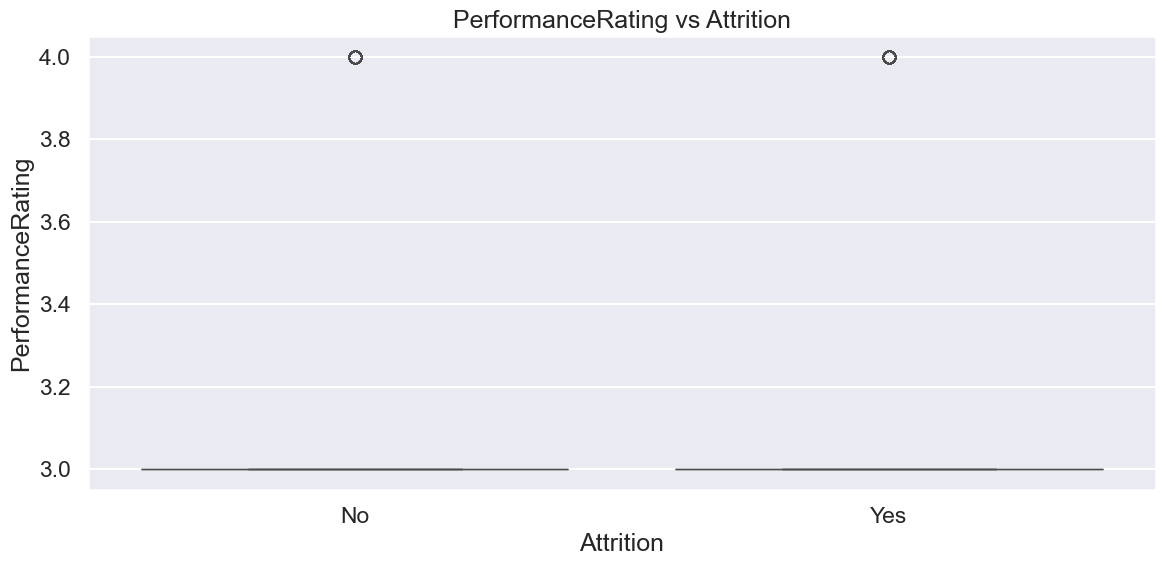

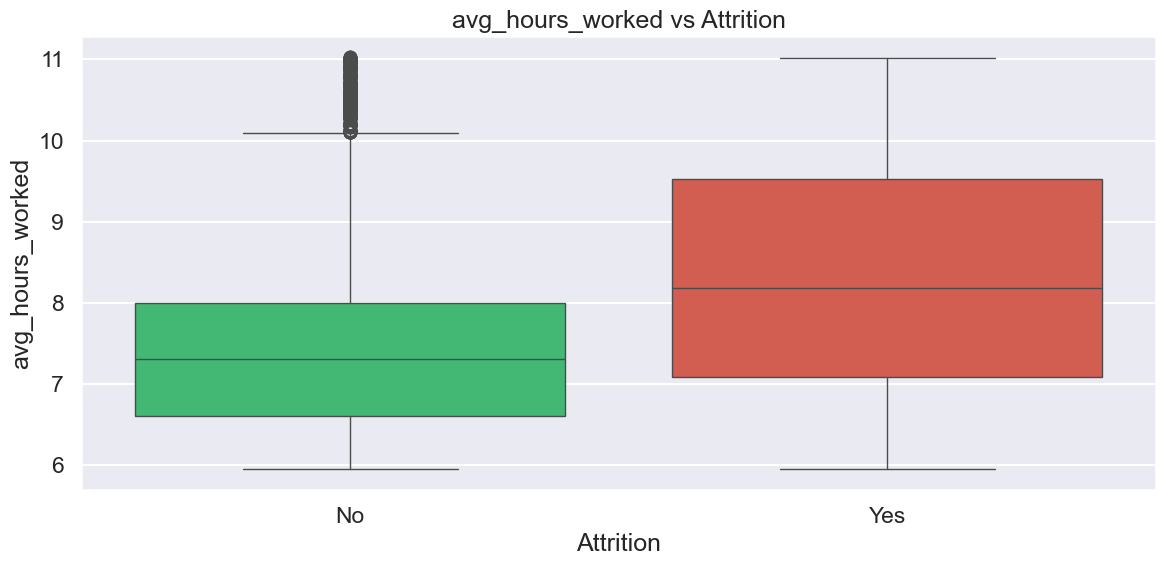

VARIABLES CATÉGORIELLES vs ATTRITION


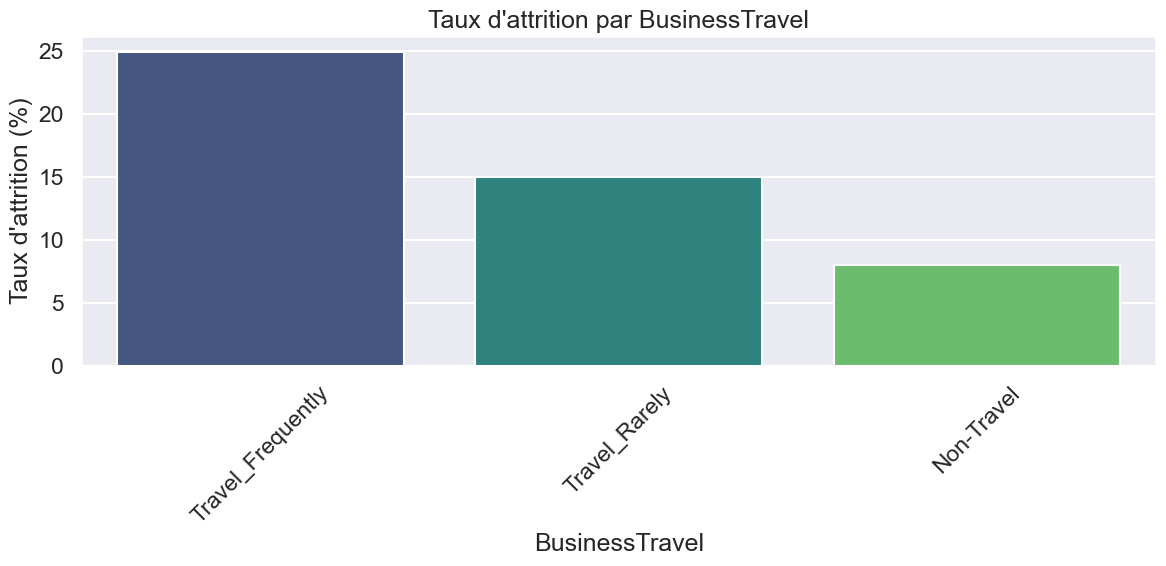

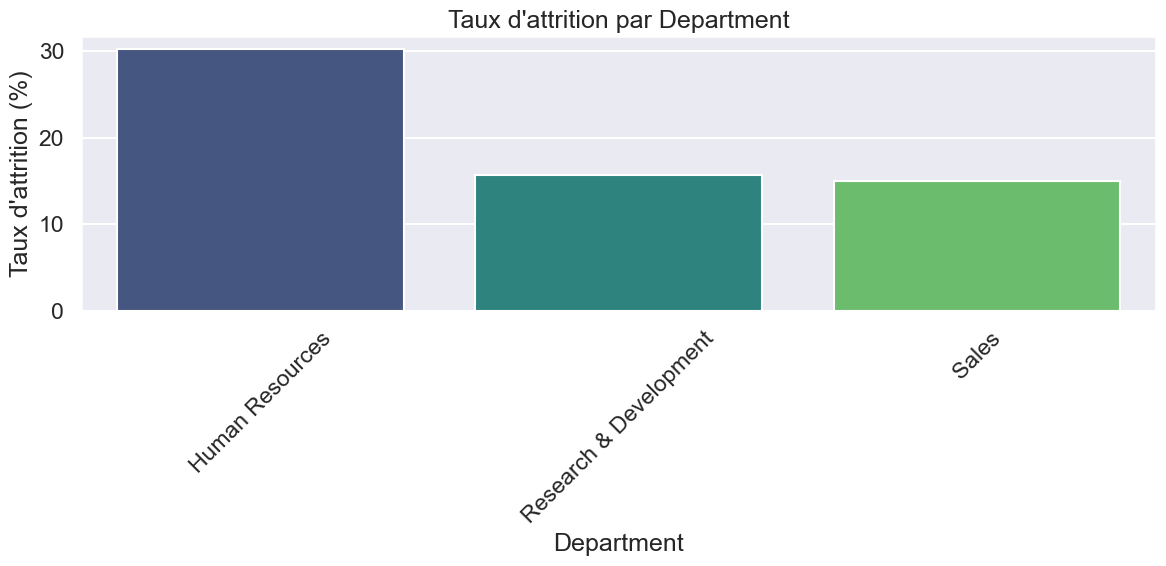

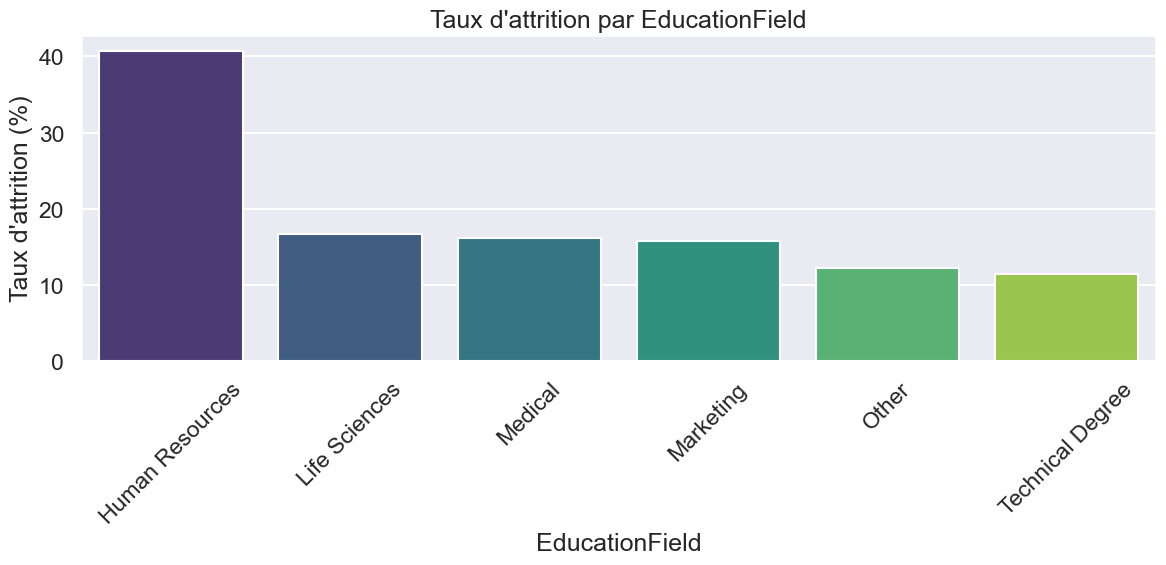

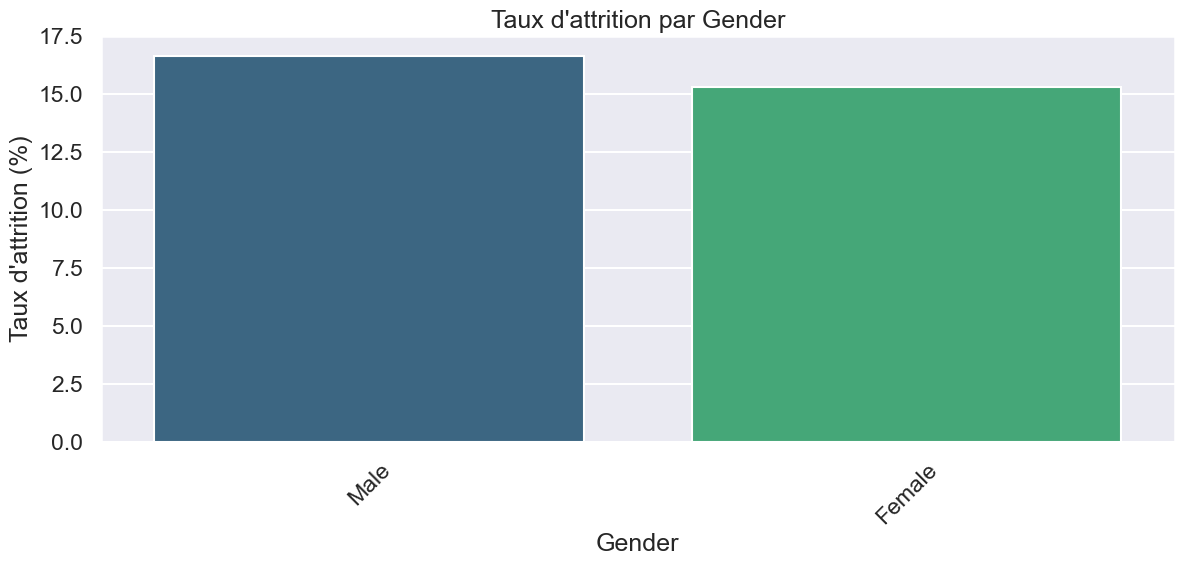

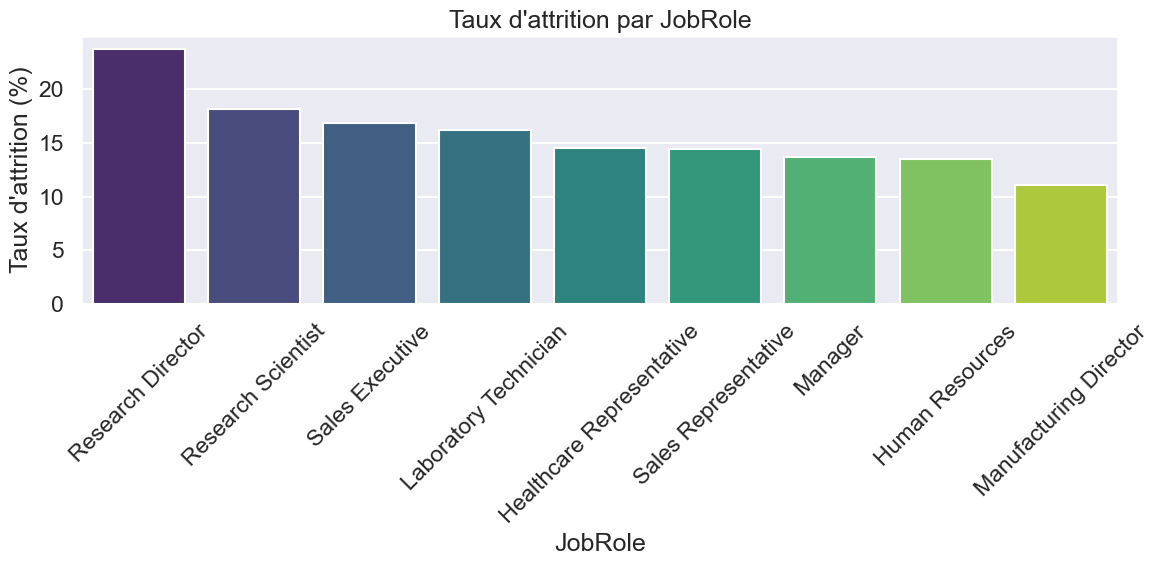

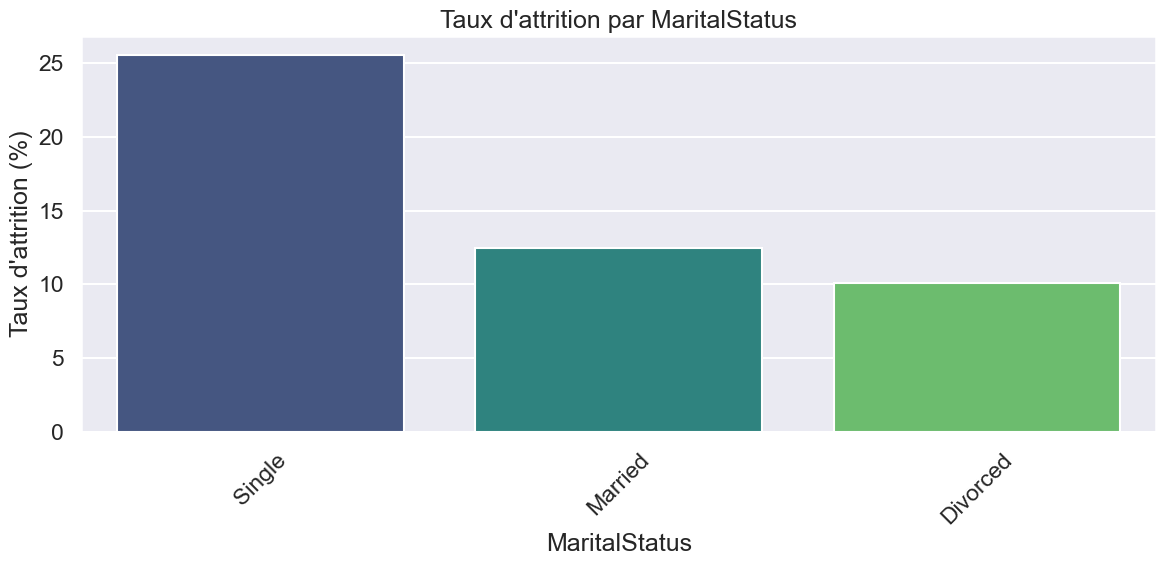

In [32]:
attrition_yes = employee_data[employee_data['Attrition'] == 'Yes']
attrition_no  = employee_data[employee_data['Attrition'] == 'No']

# VARIABLES NUMÉRIQUES vs ATTRITION — Boxplot
print('VARIABLES NUMÉRIQUES vs ATTRITION (Mann-Whitney U)')

results_num = []
for column in numerical_columns:

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Attrition', y=column, data=employee_data,
                palette=['#2ecc71', '#e74c3c'])
    plt.title(f'{column} vs Attrition')
    plt.tight_layout()
    plt.show()

# VARIABLES CATÉGORIELLES vs ATTRITION — Taux d'attrition
print('VARIABLES CATÉGORIELLES vs ATTRITION')

results_cat = []
for column in categorical_columns:
    if column == 'Attrition':
        continue

    attrition_rate = employee_data.groupby(column)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    attrition_rate.columns = [column, "Taux d'attrition (%)"]
    attrition_rate = attrition_rate.sort_values("Taux d'attrition (%)", ascending=False)

    contingency = pd.crosstab(employee_data[column], employee_data['Attrition'])

    plt.figure(figsize=(12, 6))
    sns.barplot(x=column, y="Taux d'attrition (%)", data=attrition_rate, palette='viridis')
    plt.title(f"Taux d'attrition par {column}")
    plt.xticks(rotation=45)
    plt.ylabel("Taux d'attrition (%)")
    plt.tight_layout()
    plt.show()

## 9. Analyse dédiée — Heures travaillées vs Attrition

La variable `avg_hours_worked`, issue du feature engineering sur les fichiers de badgeage, mérite une analyse visuelle approfondie.

On cherche à valider l'hypothèse suivante : **les employés qui travaillent davantage sont-ils plus susceptibles de quitter l'entreprise ?**

On combine un boxplot (comparaison des médianes) et un graphe de densité KDE (visualisation complète des distributions par groupe).

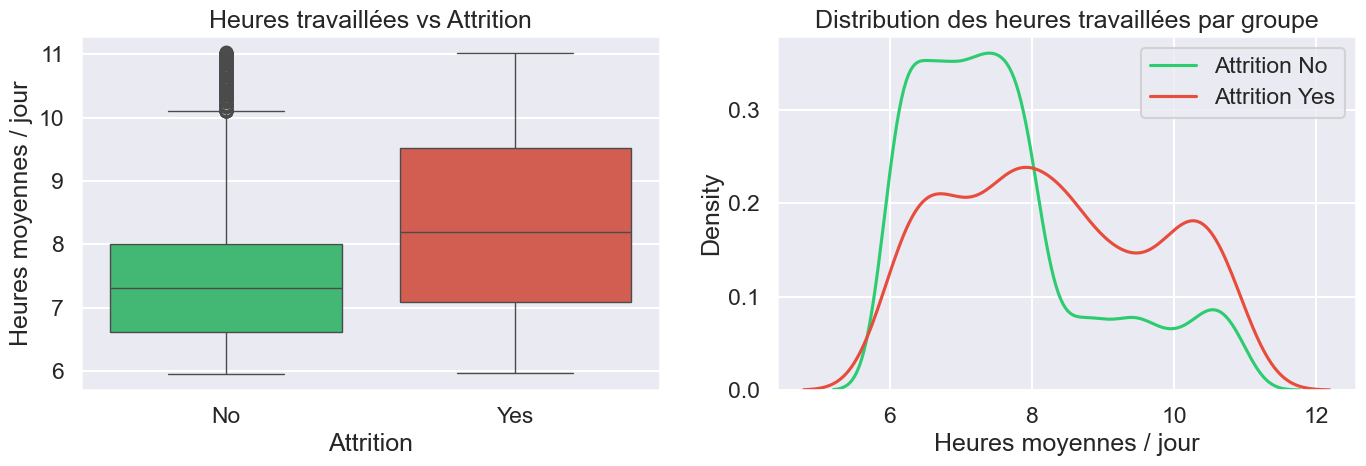

Statistiques heures travaillées par groupe :
            count  mean  std  min  25%  50%  75%   max
Attrition                                             
No        3699.00  7.58 1.28 5.95 6.61 7.31 8.00 11.03
Yes        711.00  8.32 1.46 5.96 7.09 8.19 9.53 11.02


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x='Attrition', y='avg_hours_worked', data=employee_data,
            palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Heures travaillées vs Attrition')
axes[0].set_ylabel('Heures moyennes / jour')

# Distribution KDE par groupe
for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
    subset = employee_data[employee_data['Attrition'] == label]['avg_hours_worked']
    sns.kdeplot(subset, label=f'Attrition {label}', color=color, ax=axes[1])
axes[1].set_title('Distribution des heures travaillées par groupe')
axes[1].set_xlabel('Heures moyennes / jour')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Statistiques heures travaillées par groupe :')
print(employee_data.groupby('Attrition')['avg_hours_worked'].describe().round(2))

## 10. Matrice de corrélation

La heatmap de corrélation permet de visualiser les relations linéaires entre toutes les variables numériques.

Elle permet d'identifier :
- Les variables **fortement corrélées entre elles** (risque de multicolinéarité)
- Les variables **les plus corrélées à `Attrition`** (après encodage binaire : `Yes` → 1, `No` → 0)

> **Rappel :** la corrélation mesure uniquement les relations **linéaires**. Une corrélation faible ne signifie pas absence de relation non linéaire.

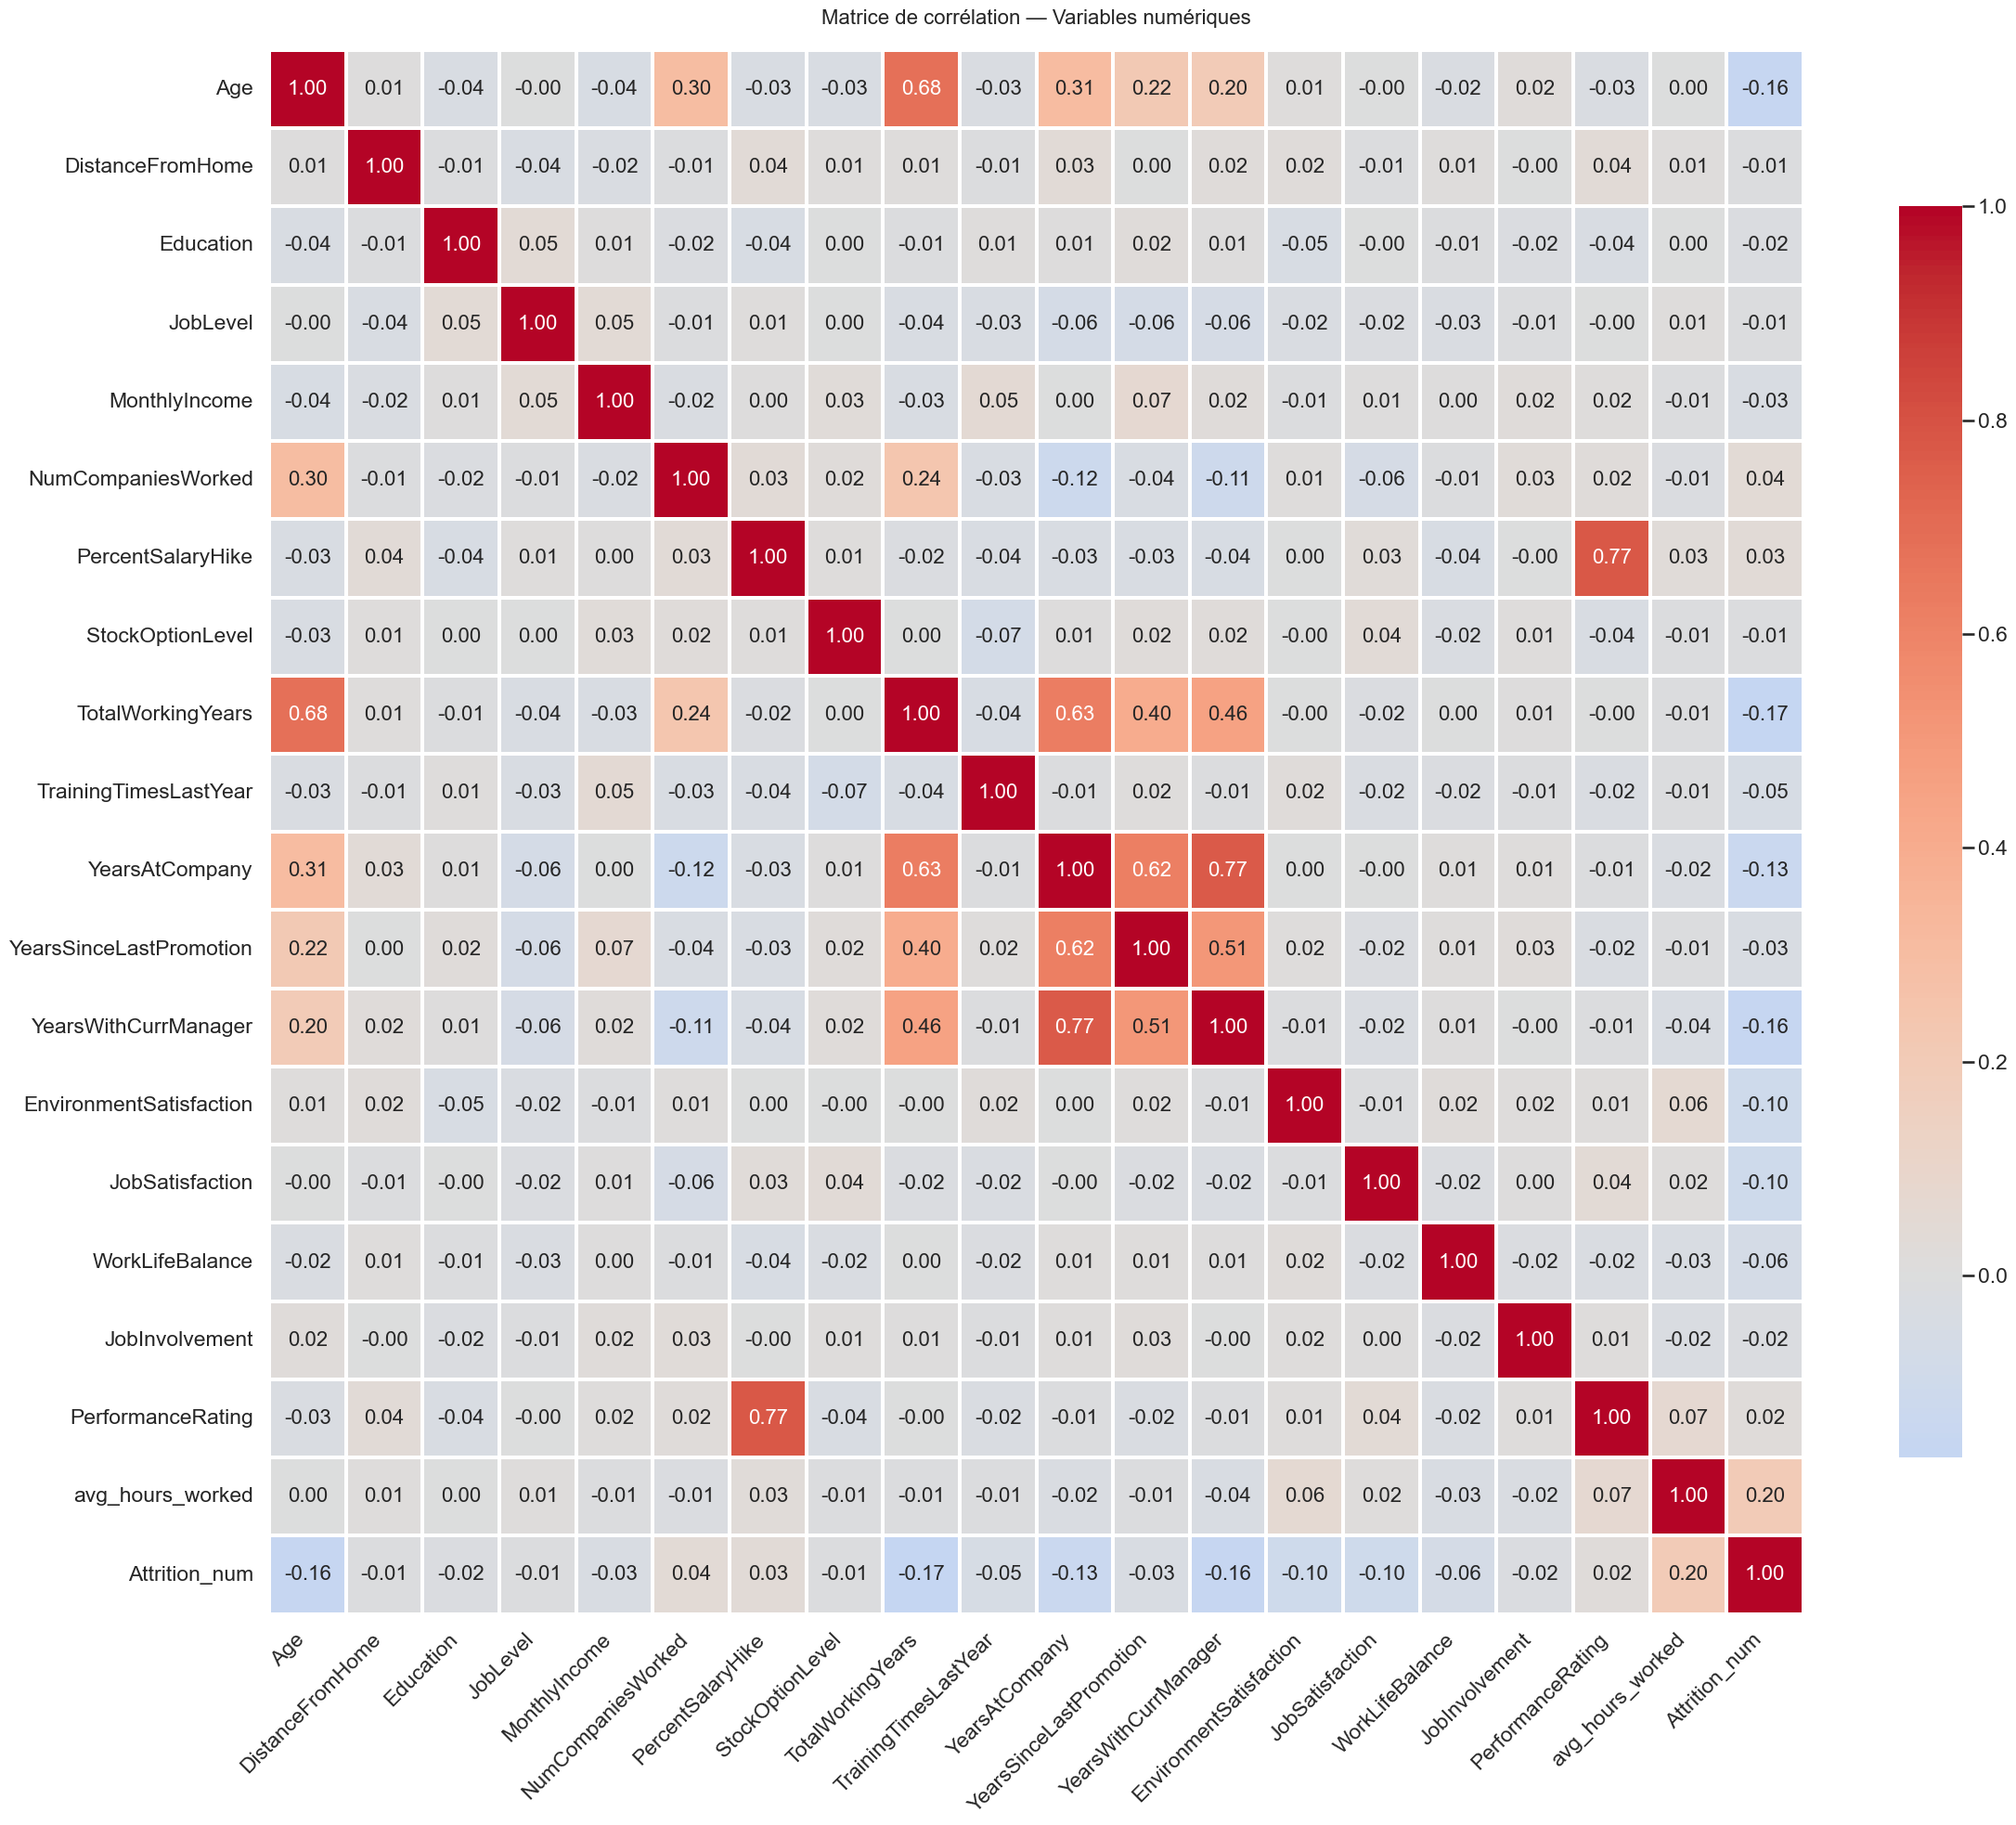

Corrélations avec Attrition (triées par valeur absolue) :
avg_hours_worked           0.20
TotalWorkingYears         -0.17
Age                       -0.16
YearsWithCurrManager      -0.16
YearsAtCompany            -0.13
JobSatisfaction           -0.10
EnvironmentSatisfaction   -0.10
WorkLifeBalance           -0.06
TrainingTimesLastYear     -0.05
NumCompaniesWorked         0.04
YearsSinceLastPromotion   -0.03
PercentSalaryHike          0.03
MonthlyIncome             -0.03
PerformanceRating          0.02
JobInvolvement            -0.02
Education                 -0.02
JobLevel                  -0.01
DistanceFromHome          -0.01
StockOptionLevel          -0.01
Name: Attrition_num, dtype: float64


In [34]:
corr_data = employee_data.copy()
corr_data['Attrition_num'] = corr_data['Attrition'].map({'Yes': 1, 'No': 0})

corr_cols   = [c for c in numerical_columns + ['Attrition_num'] if c in corr_data.columns]
corr_matrix = corr_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=1.5,
    cbar_kws={'shrink': 0.8},
    ax=ax,
    annot_kws={'size': 16}
)
ax.set_title('Matrice de corrélation — Variables numériques', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Corrélations avec Attrition (triées par valeur absolue) :')
print(corr_matrix['Attrition_num'].drop('Attrition_num').sort_values(key=abs, ascending=False))

## 11. Conclusion de l'analyse exploratoire

L'analyse exploratoire a permis d'identifier les principaux facteurs associés à l'attrition des employés chez HumanForYou. Les tests statistiques (Mann-Whitney U et Chi²) confirment la significativité de la majorité des relations observées.

---

### Facteurs numériques significatifs

- **Charge de travail élevée** (`avg_hours_worked`) : les employés qui travaillent le plus d'heures sont proportionnellement plus nombreux à quitter l'entreprise — lien entre surcharge et désengagement.
- **Profil junior** (`TotalWorkingYears`, `Age`) : les employés jeunes avec peu d'ancienneté globale sont plus susceptibles de partir — mobilité professionnelle en début de carrière.
- **Relation avec le manager** (`YearsWithCurrManager`) : une longue collaboration avec le manager actuel est associée à une plus grande fidélité — la stabilité managériale est un facteur de rétention.
- **Satisfaction au travail** (`JobSatisfaction`, `EnvironmentSatisfaction`) : les employés insatisfaits de leur poste ou de leur environnement partent davantage.

### Facteurs catégoriels significatifs

- **Statut marital** (`MaritalStatus`) : les célibataires présentent un taux d'attrition nettement plus élevé — moins d'attaches géographiques ou familiales.
- **Fréquence des déplacements** (`BusinessTravel`) : les employés qui voyagent fréquemment (`Travel_Frequently`) quittent bien plus l'entreprise — fatigue liée aux contraintes de mobilité.
- **Métier** (`JobRole`) : certains postes (Sales Representative notamment) affichent des taux d'attrition structurellement plus élevés que d'autres rôles.

---

### Points de vigilance pour la modélisation

| Point | Détail |
|---|---|
| **Déséquilibre de classes** | ~84% No / ~16% Yes → appliquer SMOTE ou class_weight |
| **Multicolinéarité** | `Age`, `TotalWorkingYears`, `YearsAtCompany` fortement corrélées entre elles |
| **Variable peu discriminante** | `PerformanceRating` ne prend que les valeurs 3 et 4 → à considérer pour suppression |
| **Non-linéarité** | Certaines relations sont non linéaires — Random Forest ou XGBoost pourront mieux les capturer ? |

---

> Ces observations orienteront le choix des variables et des algorithmes dans la phase de modélisation.

## 12. Préparation des données pour la classification


### Création du pipeline pour nos modèles

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- 12.1 Préparation de la cible et des features ---
df_model = preprocessed_data.copy()

# Encodage de la cible
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# On garde EmployeeID pour que le transformer puisse mapper les heures travaillées
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

# --- 12.2 Train/Test split stratifié ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille train : {X_train.shape[0]} lignes | Taille test : {X_test.shape[0]} lignes")

# --- 12.3 Définition des Pipelines de transformation ---

# Liste des colonnes après engineering et cleaning
final_num_features = [
    'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 
    'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 
    'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 
    'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 
    'PerformanceRating', 'avg_hours_worked'
]

final_cat_features = [
    'BusinessTravel', 'Department', 'EducationField', 'JobRole'
]

# Pipeline numérique : Imputation + Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline catégoriel : Imputation + Encodage
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# ColumnTransformer final
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, final_num_features),
    ('cat', cat_transformer, final_cat_features)
])

# Pipeline de préparation global (Engineering + Cleaning + Preprocessing)
data_prep_pipeline = Pipeline(steps=[
    ('engineer', HoursWorkedEngineer(in_time, out_time)),
    ('cleaner', CleaningTransformer()),
    ('preprocessor', preprocessor)
])

# NOTE : Nous n'appliquons pas fit_transform ici pour l'intégrer directement 
# dans un Pipeline global avec le modèle. Cela garantit qu'aucune information 
# du set de validation ne fuite pendant la validation croisée (Section 15).


Taille train : 3528 lignes | Taille test : 882 lignes


## 13. Modélisation — Régression Logistique

### Pourquoi la régression logistique ?
- **Cible binaire** (Yes/No) → modèle de classification adapté.
- **Interprétabilité** : les coefficients permettent de comprendre l'effet de chaque variable sur la probabilité d'attrition, ce qui est cohérent avec notre analyse bivariée.
- **Référence solide** : c'est le modèle de base en classification supervisée, idéal avant de tester des modèles plus complexes.

### Gestion du déséquilibre de classes
Le paramètre `class_weight='balanced'` ajuste automatiquement les poids des classes en fonction de leur fréquence :
- La classe minoritaire (Yes = 16%) reçoit un poids plus élevé
- Le modèle ne sera pas biaisé vers la prédiction systématique de "No"

### Métriques d'évaluation
- **Matrice de confusion** : visualise les vrais/faux positifs et négatifs
- **F1-score** : équilibre précision et rappel — adapté aux classes déséquilibrées
- **AUC-ROC** : mesure la capacité du modèle à discriminer les deux classes (0.5 = aléatoire, 1.0 = parfait)
- **Recall (sensibilité)** : prioritaire ici — mieux vaut identifier trop d'employés à risque que d'en manquer

AUC-ROC : 0.799

Rapport de classification :
              precision    recall  f1-score   support

   Reste (0)       0.94      0.73      0.82       740
  Quitte (1)       0.35      0.75      0.48       142

    accuracy                           0.73       882
   macro avg       0.64      0.74      0.65       882
weighted avg       0.84      0.73      0.77       882



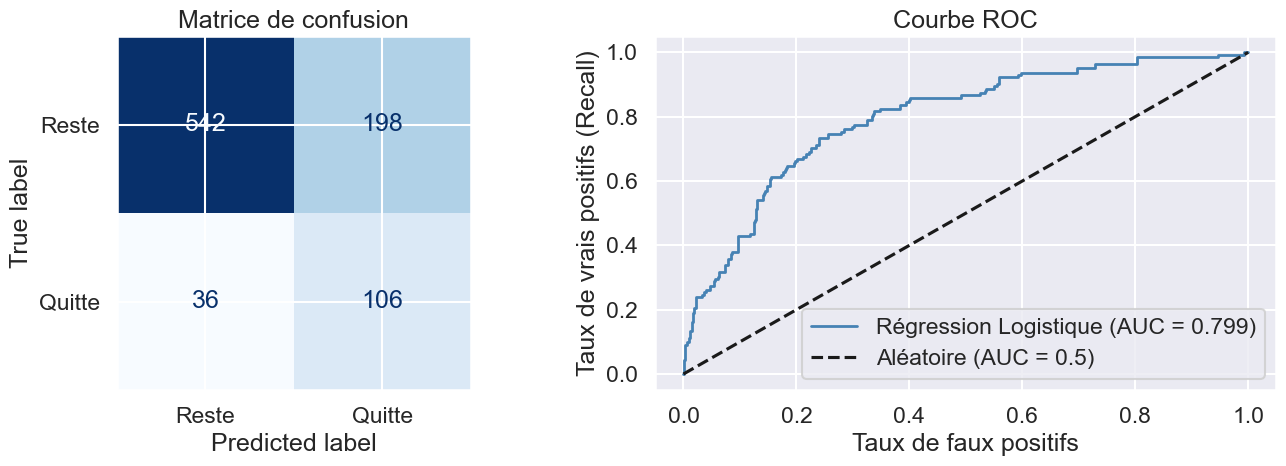

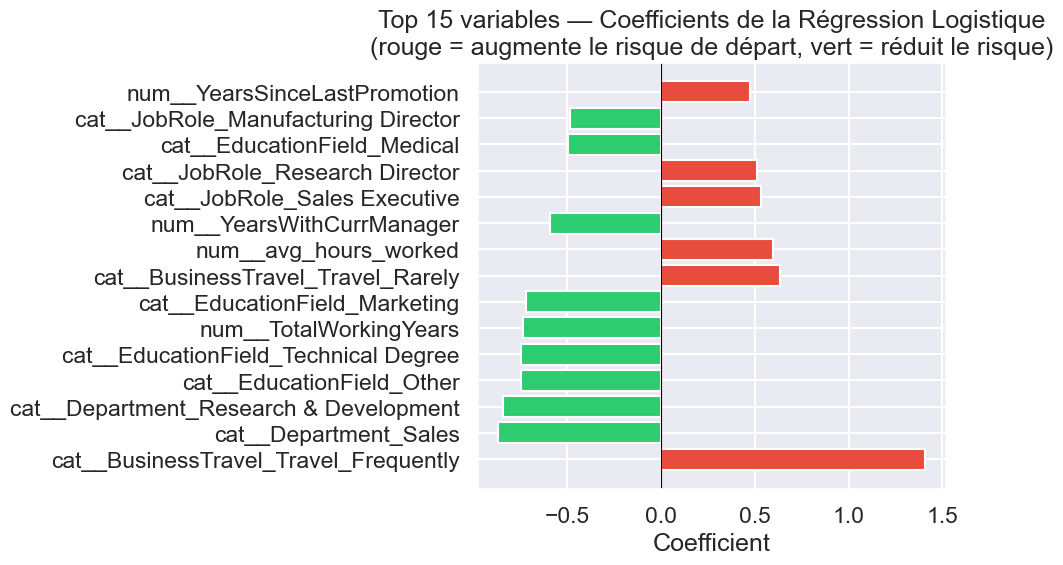


Top 15 variables les plus influentes :
                              Variable  Coefficient
 cat__BusinessTravel_Travel_Frequently         1.41
                 cat__Department_Sales        -0.87
cat__Department_Research & Development        -0.84
             cat__EducationField_Other        -0.75
  cat__EducationField_Technical Degree        -0.75
                num__TotalWorkingYears        -0.74
         cat__EducationField_Marketing        -0.72
     cat__BusinessTravel_Travel_Rarely         0.64
                 num__avg_hours_worked         0.60
             num__YearsWithCurrManager        -0.59
          cat__JobRole_Sales Executive         0.53
        cat__JobRole_Research Director         0.51
           cat__EducationField_Medical        -0.50
   cat__JobRole_Manufacturing Director        -0.49
          num__YearsSinceLastPromotion         0.47


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# --- 13.1 Construction du Pipeline global ---
# On combine la préparation (Engineering + Cleaning + Preprocessing) et le modèle
lr_pipeline = Pipeline(steps=[
    ('prep', data_prep_pipeline),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# --- 13.2 Entraînement ---
lr_pipeline.fit(X_train, y_train)

# --- 13.3 Prédictions ---
y_pred       = lr_pipeline.predict(X_test)
y_pred_proba = lr_pipeline.predict_proba(X_test)[:, 1]

# --- 13.4 Métriques ---
auc_score = roc_auc_score(y_test, y_pred_proba)
print("=" * 50)
print(f"AUC-ROC : {auc_score:.3f}")
print("=" * 50)
print()
print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=['Reste (0)', 'Quitte (1)']))

# --- 13.4 Matrice de confusion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                               display_labels=['Reste', 'Quitte'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'Régression Logistique (AUC = {auc_score:.3f})', color='steelblue', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs (Recall)')
axes[1].set_title('Courbe ROC')
axes[1].legend()
plt.tight_layout()
plt.show()

# --- 13.5 Interprétation des coefficients ---
# On récupère le modèle et les noms de colonnes après encodage
final_model   = lr_pipeline.named_steps['model']
feature_names = lr_pipeline.named_steps['prep'].named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coefficient': final_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coefficient']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 variables — Coefficients de la Régression Logistique\n'
             '(rouge = augmente le risque de départ, vert = réduit le risque)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print("\nTop 15 variables les plus influentes :")
print(coef_df.to_string(index=False))

## 14. Modélisation — Comparaison de modèles (Éthique : Transparence et Explicabilité)

Nous comparons plusieurs algorithmes pour prédire l'attrition. 

**Note éthique (Transparence et Robustesse) :**
- **Transparence** : Nous privilégions la **Régression Logistique** comme modèle de référence. Son caractère linéaire permet d'interpréter les coefficients et d'expliquer les prédictions, évitant ainsi l'effet "boîte noire".
- **Robustesse** : Le déséquilibre des classes (84% vs 16%) est traité via `class_weight='balanced'`. Cela évite que le modèle ignore les départs au profit de la classe majoritaire.
- **Sécurité** : Les métriques de **Recall** et **AUC-ROC** sont privilégiées car il est plus préjudiciable pour l'entreprise de manquer un employé sur le départ (faux négatif) que de proposer une action de rétention à un employé qui n'en avait pas besoin (faux positif).

Les modèles testés :
- **Régression Logistique**
- **SVM (Support Vector Machine)**
- **Perceptron**
- **KNN (K Nearest Neighbors)**
- **Arbre de Décision (Decision Tree)**
- **Forêt Aléatoire (Random Forest)**

**Méthodologie :**
1. **Entraînement et Test** : boucle sur chaque modèle avec gestion du déséquilibre (`class_weight='balanced'`). Nous allons utiliser `GridSearchCV` pour optimiser les hyperparamètres de nos modèles. L'objectif est de trouver la combinaison qui maximise le **F1-Score** (équilibre entre précision et rappel) tout en contrôlant le surapprentissage.
2. **Évaluation** : comparaison via Accuracy, F1-Score et ROC AUC.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
import time

# --- Définition des modèles et des grilles de paramètres ---
# Chaque modèle est encapsulé dans un Pipeline :
# 1) 'prep' : prétraitement (imputation, encodage, scaling)
# 2) 'model' : classifieur à optimiser
# Le GridSearchCV testera toutes les combinaisons de la grille "params".

tuning_configs = {
    "Logistic Regression": {
        "pipeline": Pipeline(steps=[
            ('prep', data_prep_pipeline),
            # class_weight='balanced' : corrige le déséquilibre de classes
            # max_iter=1000 : évite les non-convergences
            ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
        ]),
        "params": {
            # C : inverse de la régularisation (petit C => régularisation forte)
            'model__C': [0.1, 1, 10],
            # solver : algorithme d'optimisation (impact vitesse + compatibilité)
            'model__solver': ['liblinear', 'lbfgs', 'saga', 'newton-cg'],
            # dual : formulation duale (ici fixé à False pour compatibilité générale)
            'model__dual': [False]
        }
    },

    "Perceptron": {
        "pipeline": Pipeline(steps=[
            ('prep', data_prep_pipeline),
            # class_weight='balanced' : utile si classe positive minoritaire
            ('model', Perceptron(class_weight='balanced', random_state=42))
        ]),
        "params": {
            # penalty : type de régularisation (None, L1, L2, ElasticNet)
            'model__penalty': [None, 'l2', 'l1', 'elasticnet'],
            # alpha : intensité de la régularisation (plus grand => modèle plus simple)
            'model__alpha': [0.0001, 0.001, 0.01],
            # max_iter : nombre maximal d'itérations d'entraînement
            'model__max_iter': [1000, 2000]
        }
    },

    "SVM": {
        "pipeline": Pipeline(steps=[
            ('prep', data_prep_pipeline),
            # probability=True : nécessaire pour predict_proba (AUC, calibration)
            ('model', SVC(class_weight='balanced', probability=True, random_state=42, max_iter=1000))
        ]),
        "params": {
            # C : pénalité des erreurs de classification (marge souple/stricte)
            'model__C': [0.1, 1, 10],
            # kernel : transformation de l'espace (linéaire/non-linéaire)
            'model__kernel': ['rbf', 'poly', 'sigmoid'],
            # gamma : portée d'influence d'un point (rbf/poly/sigmoid)
            'model__gamma': ['scale', 'auto']
        }
    },

    "KNN": {
        "pipeline": Pipeline(steps=[
            ('prep', data_prep_pipeline),
            ('model', KNeighborsClassifier())
        ]),
        "params": {
            # n_neighbors : nombre de voisins considérés pour voter
            'model__n_neighbors': [3, 5, 7],
            # weights : vote uniforme ou pondéré par la distance
            'model__weights': ['uniform', 'distance'],
            # algorithm : méthode de recherche des voisins (perf calcul)
            'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
        }
    },

    "Decision Tree": {
        "pipeline": Pipeline(steps=[
            ('prep', data_prep_pipeline),
            # class_weight='balanced' : réduit le biais vers la classe majoritaire
            ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))
        ]),
        "params": {
            # max_depth : profondeur max (contrôle le surapprentissage)
            'model__max_depth': [None, 10, 20, 30],
            # min_samples_split : nb min d'échantillons pour diviser un nœud
            'model__min_samples_split': [2, 5, 10],
            # max_features : nb de variables testées à chaque split
            'model__max_features': ['sqrt', 'log2', None]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline(steps=[
            ('prep', data_prep_pipeline),
            # Ensemble d'arbres pour réduire variance et surapprentissage
            ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
        ]),
        "params": {
            # n_estimators : nombre d'arbres dans la forêt
            'model__n_estimators': [100, 200],
            # max_depth : profondeur max de chaque arbre
            'model__max_depth': [None, 15, 30],
            # min_samples_split : nb min d'échantillons pour faire un split
            'model__min_samples_split': [2, 5, 10],
            # max_features : nb de variables candidates par split
            'model__max_features': ['sqrt', 'log2', None]
        }
    }
}

best_models = {}
tuning_results = []

print("Début du Fine-tuning global...\n")

for name, config in tuning_configs.items():
    start_time = time.time()
    print(f"Optimisation de {name} en cours...")
    
    grid_search = GridSearchCV(
        estimator=config["pipeline"], 
        param_grid=config["params"], 
        cv=5, 
        scoring='f1', 
        n_jobs=-1,
        return_train_score=True
    )
    # On passe X_train brut, le pipeline s'occupe de l'encodage et du scaling par fold
    grid_search.fit(X_train, y_train)
    
    best_pipeline = grid_search.best_estimator_
    best_models[name] = best_pipeline
    
    # Évaluation sur le jeu de Test
    y_pred = best_pipeline.predict(X_test)
    f1 = f1_score(y_test, y_pred)

    # Récupération des scores de validation et d'entraînement pour le meilleur modèle
    best_idx = grid_search.best_index_
    cv_train_f1 = grid_search.cv_results_['mean_train_score'][best_idx]
    cv_val_f1 = grid_search.cv_results_['mean_test_score'][best_idx]

    # Certains modèles (ex: Perceptron) n'ont pas predict_proba
    if hasattr(best_pipeline, "predict_proba"):
        y_score = best_pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(best_pipeline, "decision_function"):
        y_score = best_pipeline.decision_function(X_test)
    else:
        y_score = y_pred

    auc = roc_auc_score(y_test, y_score)
    
    duration = time.time() - start_time
    
    tuning_results.append({
        'Modèle': name,
        'Best Params': grid_search.best_params_,
        'F1 Train (CV)': round(cv_train_f1, 4),
        'F1 Val (CV)': round(cv_val_f1, 4),
        'Gap (Train-Val)': round(cv_train_f1 - cv_val_f1, 4),
        'F1 Test (Optimisé)': round(f1, 4),
        'ROC AUC (Optimisé)': round(auc, 4),
        'Temps (s)': round(duration, 2)
    })
    
    print(f"  -> Terminé en {duration:.2f}s")
    print(f"  -> Meilleurs paramètres : {grid_search.best_params_}")
    print(f"  -> F1 Test : {f1:.3f} | AUC : {auc:.3f}\n")
    
    best_models[name] = best_pipeline


Début du Fine-tuning global...

Optimisation de Logistic Regression en cours...
  -> Terminé en 28.17s
  -> Meilleurs paramètres : {'model__C': 10, 'model__dual': False, 'model__solver': 'lbfgs'}
  -> F1 Test : 0.477 | AUC : 0.799

Optimisation de Perceptron en cours...
  -> Terminé en 18.33s
  -> Meilleurs paramètres : {'model__alpha': 0.0001, 'model__max_iter': 1000, 'model__penalty': 'elasticnet'}
  -> F1 Test : 0.384 | AUC : 0.678

Optimisation de SVM en cours...
  -> Terminé en 22.33s
  -> Meilleurs paramètres : {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'poly'}
  -> F1 Test : 0.965 | AUC : 0.994

Optimisation de KNN en cours...
  -> Terminé en 23.84s
  -> Meilleurs paramètres : {'model__algorithm': 'auto', 'model__n_neighbors': 7, 'model__weights': 'distance'}
  -> F1 Test : 0.978 | AUC : 0.987

Optimisation de Decision Tree en cours...
  -> Terminé en 38.08s
  -> Meilleurs paramètres : {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_sp

## 15. Importance des variables

On extrait ici les importances des variables du meilleur modèle identifié par la recherche de grille. Cette visualisation permet d'identifier les leviers d'action pour HumanForYou.

Synthèse des modèles optimisés :


,Modèle,Best Params,F1 Train (CV),F1 Val (CV),Gap (Train-Val),F1 Test (Optimisé),ROC AUC (Optimisé),Temps (s)
5,Random Forest,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 200}",0.999800,0.936700,0.063100,0.989300,0.994600,83.520000
3,KNN,"{'model__algorithm': 'auto', 'model__n_neighbors': 7, 'model__weights': 'distance'}",1.000000,0.926800,0.073200,0.978400,0.986700,23.840000
2,SVM,"{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'poly'}",0.999300,0.922200,0.077100,0.965300,0.993600,22.330000
4,Decision Tree,"{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_split': 2}",0.996300,0.902700,0.093600,0.958000,0.978200,38.080000
0,Logistic Regression,"{'model__C': 10, 'model__dual': False, 'model__solver': 'lbfgs'}",0.469800,0.451200,0.018600,0.477500,0.799300,28.170000
1,Perceptron,"{'model__alpha': 0.0001, 'model__max_iter': 1000, 'model__penalty': 'elasticnet'}",0.353900,0.364400,-0.010500,0.383800,0.678100,18.330000


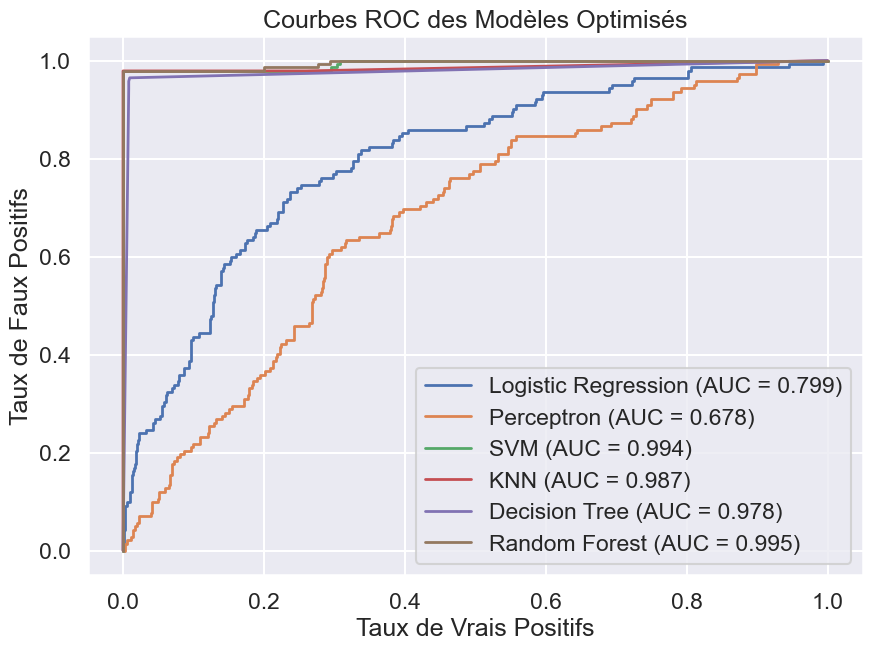


--- Meilleur modèle final : Random Forest ---
              precision    recall  f1-score   support

   Reste (0)       1.00      1.00      1.00       740
  Quitte (1)       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882



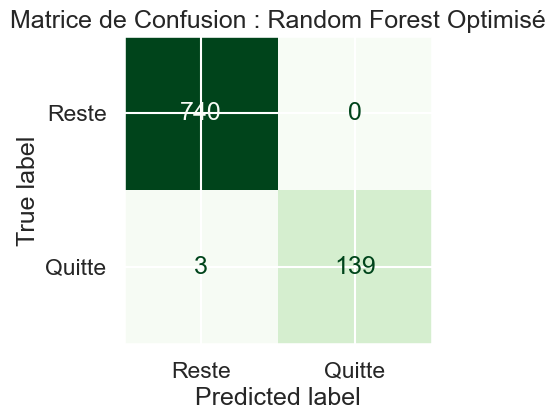

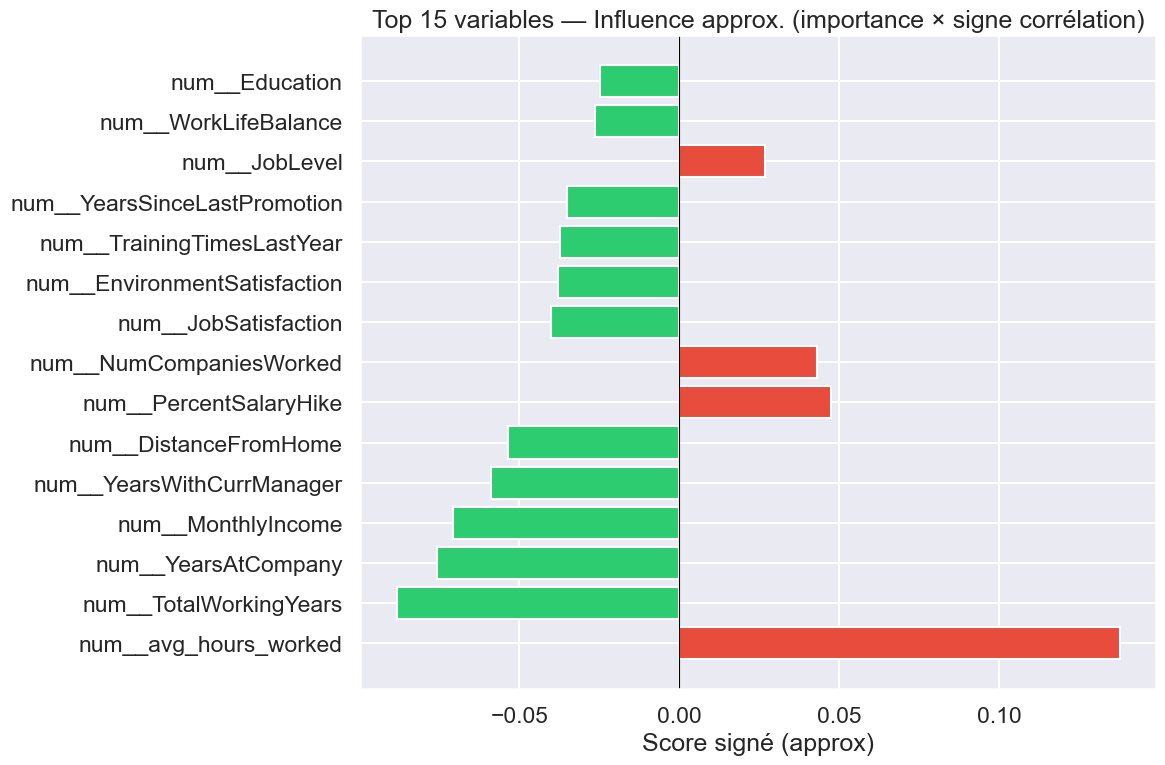

,Variable,Importance,Influence (approx)
17,num__avg_hours_worked,0.14,Positive
7,num__TotalWorkingYears,0.09,Négative
9,num__YearsAtCompany,0.08,Négative
3,num__MonthlyIncome,0.07,Négative
11,num__YearsWithCurrManager,0.06,Négative
0,num__DistanceFromHome,0.05,Négative
5,num__PercentSalaryHike,0.05,Positive
4,num__NumCompaniesWorked,0.04,Positive
13,num__JobSatisfaction,0.04,Négative
12,num__EnvironmentSatisfaction,0.04,Négative


In [ ]:
# --- 15.1 Comparaison des modèles optimisés ---
df_tuned_results = pd.DataFrame(tuning_results).sort_values(by='F1 Test (Optimisé)', ascending=False)
print("Synthèse des modèles optimisés :")
display(df_tuned_results.style.set_caption("Comparaison des modèles après fine-tuning global").background_gradient(subset=['F1 Test (Optimisé)'], cmap='YlGn').background_gradient(subset=['ROC AUC (Optimisé)'], cmap='YlGn'))

# --- 15.2 Courbe ROC des modèles optimisés ---
plt.figure(figsize=(10, 7))

for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', lw=2)

plt.xlabel('Taux de Vrais Positifs')
plt.ylabel('Taux de Faux Positifs')
plt.title('Courbes ROC des Modèles Optimisés')
plt.legend()
plt.grid(True)
plt.show()

# --- 15.3 Analyse du meilleur modèle global ---
best_overall_name = df_tuned_results.iloc[0]['Modèle']
best_overall_model = best_models[best_overall_name]

print(f"\n--- Meilleur modèle final : {best_overall_name} ---")
y_pred_final = best_overall_model.predict(X_test)
print(classification_report(y_test, y_pred_final, target_names=['Reste (0)', 'Quitte (1)']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, 
                                        display_labels=['Reste', 'Quitte'],
                                        cmap='Greens', ax=ax, colorbar=False)
ax.set_title(f'Matrice de Confusion : {best_overall_name} Optimisé')
plt.show()

# --- 15.4 Importance des variables (uniquement si le modèle le supporte) ---
model_step = best_overall_model.named_steps['model'] if hasattr(best_overall_model, "named_steps") else best_overall_model
prep_step = best_overall_model.named_steps['prep'] if hasattr(best_overall_model, "named_steps") and 'prep' in best_overall_model.named_steps else None

if prep_step is not None and 'preprocessor' in prep_step.named_steps:
    feature_names = prep_step.named_steps['preprocessor'].get_feature_names_out()
else:
    feature_names = X_train.columns.to_numpy()

if hasattr(model_step, "coef_"):
    # Cas modèles linéaires (ex: Logistic Regression) : signe exact des coefficients
    coefs = model_step.coef_.ravel()
    coef_df = pd.DataFrame({
        "Variable": feature_names,
        "Coefficient": coefs
    }).sort_values("Coefficient", key=np.abs, ascending=False).head(15)

    coef_df["Influence"] = np.where(coef_df["Coefficient"] > 0, "Positive", "Négative")
    colors = np.where(coef_df["Coefficient"] > 0, "#e74c3c", "#2ecc71")

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(coef_df["Variable"], coef_df["Coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Top 15 variables — Influence sur la probabilité de départ (classe 1)")
    ax.set_xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    display(coef_df[["Variable", "Coefficient", "Influence"]])

elif hasattr(model_step, "feature_importances_"):
    # Cas arbres/forêts : importance disponible, direction approximée via corrélation avec proba prédite
    if hasattr(best_overall_model, "predict_proba"):
        y_proba_best = best_overall_model.predict_proba(X_test)[:, 1]
    elif hasattr(best_overall_model, "decision_function"):
        y_proba_best = best_overall_model.decision_function(X_test)
    else:
        y_proba_best = best_overall_model.predict(X_test)

    # Utiliser les features transformées (numériques) pour éviter les erreurs sur colonnes string
    X_test_transformed = prep_step.transform(X_test) if prep_step is not None else X_test.values
    if hasattr(X_test_transformed, "toarray"):
        X_test_transformed = X_test_transformed.toarray()

    signs = []
    y_std = np.std(y_proba_best)
    for i in range(X_test_transformed.shape[1]):
        x_col = X_test_transformed[:, i]
        if np.std(x_col) == 0 or y_std == 0:
            signs.append(0.0)
        else:
            corr = np.corrcoef(x_col, y_proba_best)[0, 1]
            signs.append(0.0 if np.isnan(corr) else np.sign(corr))

    imp_df = pd.DataFrame({
        "Variable": feature_names,
        "Importance": model_step.feature_importances_,
        "Direction (approx)": np.array(signs)
    })

    imp_df["Score signé (approx)"] = imp_df["Importance"] * imp_df["Direction (approx)"]
    imp_df = imp_df.sort_values("Importance", ascending=False).head(15)
    imp_df["Influence (approx)"] = imp_df["Direction (approx)"].map({1.0: "Positive", -1.0: "Négative", 0.0: "Neutre"})

    colors = imp_df["Direction (approx)"].map({1.0: "#e74c3c", -1.0: "#2ecc71", 0.0: "#95a5a6"}).values

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(imp_df["Variable"], imp_df["Score signé (approx)"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Top 15 variables — Influence approx. (importance × signe corrélation)")
    ax.set_xlabel("Score signé (approx)")
    plt.tight_layout()
    plt.show()

    display(imp_df[["Variable", "Importance", "Influence (approx)"]])

else:
    print("Ce modèle ne fournit pas directement l'influence des variables.")

## 16. Recommandations Éthiques et Conclusion

Conformément aux engagements du projet en faveur d'une IA digne de confiance, nous formulons les recommandations suivantes pour l'utilisation opérationnelle de ce modèle par HumanForYou.

### 16.1 Gouvernance et Responsabilité
- **Comité de revue éthique** : Instaurer une instance paritaire (RH, représentants du personnel, experts IA) pour auditer périodiquement les prédictions et s'assurer de l'absence de biais dérivés (ex: discrimination indirecte via le métier).
- **Charte d'utilisation** : Rédiger une charte stipulant que le modèle est un **outil d'aide à la réflexion** et non un moteur de décision automatique. Aucune rupture de contrat ou sanction ne doit être fondée sur un score du modèle.
- **Droit de recours** : Garantir aux employés une transparence sur les critères influençant leur score (explicabilité locale) et un droit de contestation auprès d'un humain.

### 16.2 Actions RH Recommandées
Le modèle met en évidence que la **surcharge de travail** (`avg_hours_worked`) et l'**insatisfaction** sont les leviers majeurs. Nous recommandons :
- **Politique de déconnexion** : Surveiller les dépassements d'horaires et instaurer des alertes pour les managers dont les équipes dépassent 8.5h/jour en moyenne.
- **Stabilité managériale** : Valoriser la pérennité du binôme employé-manager (`YearsWithCurrManager`), facteur clé de rétention.
- **Accompagnement des juniors** : Mettre en place des programmes de tutorat renforcés pour les profils ayant peu d'expérience globale (`TotalWorkingYears`).

### 16.3 Maintenance Technique
- **Réentraînement annuel** : Le marché du travail et les attentes des employés évoluent. Les données de 2015 pourraient devenir obsolètes. Un réentraînement annuel est nécessaire pour maintenir la pertinence et la robustesse.
- **Audit des biais** : Vérifier régulièrement que les taux de faux positifs (FPR) et faux négatifs (FNR) restent équilibrés entre les différents groupes (genre, âge, départements).

**Conclusion**
Ce projet démontre qu'une approche data-driven peut éclairer les politiques RH tout en respectant un cadre éthique strict. En excluant les variables sensibles et en privilégiant l'interprétabilité, nous offrons à HumanForYou un outil performant pour améliorer durablement le bien-être au travail et réduire l'attrition.